# DATA 606 Capstone Deliverable: Machine Learning

**Author:** Brett Allen (ballen3@umbc.edu)

**Topic:** Air Traffic Controller (ATC) Communications Intelligence

*Speech Recognition and Information Extraction for Aviation Safety*

## Table of Contents

- [Setup](#setup)
  - [Imports](#imports)
  - [Configuration](#configuration)
  - [Hardware / Software Constraints](#hardware--software-constraints)
- [A. Load and Prepare Data](#a-load-and-prepare-data)
  - [Outlier Exclusion](#outlier-exclusion)
  - [Transcript Normalization for Scoring](#transcript-normalization-for-scoring)
- [B. Baseline ASR (openai/whisper-medium.en)](#b-baseline-asr-openaiwhisper-mediumen)
- [C. Model Comparison (jacktol/whisper-medium.en-fine-tuned-for-ATC)](#c-model-comparison-jacktolwhisper-mediumen-fine-tuned-for-atc)
  - [Fine-Tuning](#fine-tuning)
  - [Evaluate the Fine-Tuned Model](#evaluate-the-fine-tuned-model)
- [D. Aviation-Specific Evaluation](#d-aviation-specific-evaluation)
  - [Altitude / Heading / Runway / Frequency Accuracy](#altitude--heading--runway--frequency-accuracy)
  - [WER vs. Utterance Characteristics](#wer-vs-utterance-characteristics)
  - [Does Lower WER Mean Better Aviation-Entity Recognition?](#does-lower-wer-mean-better-aviation-entity-recognition)
- [Error Taxonomy](#error-taxonomy)
- [E. NER Dataset Curation (LLM-Assisted)](#e-ner-dataset-curation-llm-assisted)
  - [Label Schema, Constraints and Span Alignment](#label-schema-constraints-and-span-alignment)
  - [Rule-Based Hints](#rule-based-hints)
  - [Tool Calling Loop](#tool-calling-loop)
  - [Gold Set and Span-Level Scoring](#gold-set-and-span-level-scoring)
  - [Ablation: Constraints, Hints and Model Size](#ablation-constraints-hints-and-model-size)
  - [Build the Annotation Sample](#build-the-annotation-sample)
  - [Run the Annotators](#run-the-annotators)
  - [Review Routing](#review-routing)
  - [Annotation Quality Checks](#annotation-quality-checks)
  - [Manual Spot-Check](#manual-spot-check)
  - [Export: spaCy `DocBin` and BERT IOB2 JSONL](#export-spacy-docbin-and-bert-iob2-jsonl)
  - [Smoke Test: Train a spaCy NER and Measure Inference Speed](#smoke-test-train-a-spacy-ner-and-measure-inference-speed)
  - [Visual Check with displaCy](#visual-check-with-displacy)
- [Summary](#summary)

## Setup

In [1]:
!python --version

Python 3.12.4


In [2]:
!cat ../requirements.txt

# Python 3.12.x
datasets==3.2.0
transformers==5.18.0  # >=5 required for Qwen 3.5 (model_type qwen3_5); 4.57.x cannot load it
librosa==1.0.0
soundfile==0.14.0
coverage>=7.7.0  # numba's coverage integration needs coverage.types.Tracer (added in 7.7.0)
pandas==2.3.3
numpy==2.5.3
matplotlib==3.10.6
seaborn==0.13.2
scipy==1.18.1
wordcloud==1.9.4
torch==2.5.1  # NOTE: a plain install from this file pulls the CPU/default-CUDA-tag wheel;
              # this environment uses the +cu124 build (`pip install torch==2.5.1 --index-url
              # https://download.pytorch.org/whl/cu124`), which PyPI's default index won't reproduce.
accelerate==1.15.0  # must stay new enough for transformers>=4.57's Trainer (older accelerate
                    # lacks Accelerator.unwrap_model's `keep_torch_compile` kwarg it now passes)
jiwer==3.1.0

pydantic==2.13.4
spacy==3.8.9
seqeval==1.2.2
bitsandbytes==0.50.2  # 4-bit loading of Qwen3.5-4B for NER annotation on the 6 GB GPU


In [3]:
!python -m pip install -q -r ../requirements.txt

### Imports

In [4]:
%load_ext autoreload
%autoreload 2

import os

# This notebook only uses the PyTorch backend. Without this, `transformers`
# auto-probes for TensorFlow/Flax on import; in this shared environment that
# probe hits an installed TensorFlow build incompatible with a newer
# protobuf, raising (caught, non-fatal, but noisy) AttributeErrors.
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

import re
import sys
import json

import numpy as np
import pandas as pd
import torch
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import disable_progress_bars
from transformers import WhisperProcessor, WhisperForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments

# Make the reusable pipeline code in ../src importable from the notebook
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from preprocessing import DataIngestPipeline
from preprocessing.text_features import normalize_transcript
from preprocessing.vocab import (
    ATC_COMMAND_VERBS,
    ATC_NUMERAL_WORDS,
    ICAO_PHONETIC_ALPHABET,
    KNOWN_CALLSIGN_WORDS,
)

### Configuration

In [5]:
RANDOM_SEED = 42

FIGURES_DIR = os.path.join(os.getcwd(), "..", "res", "figures")

HUE_ORDER = ["atc-asr-dataset", "atcosim"]
PALETTE = {"atc-asr-dataset": "#2a78d6", "atcosim": "#eb6834"}

RESULTS_DIR = os.path.join(os.getcwd(), "..", "data", "processed", "asr_results")

# Scale toggle: a small stratified subset while prototyping/debugging this
# notebook; set to None to scale up to the full ~1,909-row held-out test set
# once the harness below is trusted.
N_EVAL_SAMPLES = 100

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASELINE_MODEL_ID = "openai/whisper-medium.en"
COMPARISON_MODEL_ID = "jacktol/whisper-medium.en-fine-tuned-for-ATC"

In [6]:
disable_progress_bars()  # keep re-runs free of noisy download/map/cast tqdm output

%matplotlib inline
sns.set_theme(style="whitegrid")

# Reused from notebooks/comprehensive_eda.ipynb for consistent figures/colors across notebooks.
os.makedirs(FIGURES_DIR, exist_ok=True)

# Per-row ASR outputs and experiment-results tables are saved here so results
# survive outside transient notebook output (data/processed/ is gitignored,
# same convention as utterances.parquet / combined_dataset/).
os.makedirs(RESULTS_DIR, exist_ok=True)

In [7]:
def save_fig(fig, name, dpi=150):
    """Save a matplotlib figure to res/figures/<name>.png for reuse in slides."""
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {os.path.relpath(path, os.getcwd())}")
    return path

### Hardware / Software Constraints
Inspect current device specs for reference prior to model loading and training.

In [8]:
import accelerate
import transformers
from importlib.metadata import version as pkg_version

print(f"Python / platform : {sys.version.splitlines()[0]}")
print(f"torch             : {torch.__version__} (CUDA build: {torch.version.cuda})")
print(f"CUDA available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU               : {props.name} ({props.total_memory / 1e9:.1f} GB VRAM)")
print(f"transformers      : {transformers.__version__}")
print(f"accelerate        : {accelerate.__version__}")
print(f"jiwer             : {pkg_version('jiwer')}")
print(f"device selected   : {DEVICE}")

Python / platform : 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:12:24) [GCC 11.2.0]
torch             : 2.5.1+cu124 (CUDA build: 12.4)
CUDA available    : True
GPU               : NVIDIA GeForce RTX 3070 Ti Laptop GPU (8.6 GB VRAM)
transformers      : 5.18.0
accelerate        : 1.15.0
jiwer             : 3.1.0
device selected   : cuda


## A. Load and Prepare Data

### Evaluation Subset Selection

> **NOTE:** The evaluation subset that will be used for ASR modeling is produced via `DataIngestPipeline`. We'll need to take it a step further by applying a stratified sub-sample for fast iteration purposes. This will be a configurable process so that we can easily scale against the full test set later with no other code changes.

### Leakage Prevention (Already Handled Upstream)

> **NOTE:** Speaker/session-level leakage prevention is handled by `DataIngestPipeline` as well. We discovered there were duplictes between the original ATCO2-ASR dataset and the new ATC-ASR dataset which led to the decision of dropping the original dataset to prevent the duplicate records appearing in train and test (e.g., leakage).

In [9]:
data_dir = "../data/"
pipeline = DataIngestPipeline(data_dir=data_dir)
combined_dataset, utterance_df = pipeline.run()  # reuses the cached corpus; no recompute here

test_df = utterance_df[utterance_df["dataset_split"] == "test"].reset_index(drop=True)
print(f"Test split: {len(test_df)} rows")
test_df["dataset_source"].value_counts()

Test split: 1909 rows


dataset_source
atcosim            1096
atc-asr-dataset     813
Name: count, dtype: int64

### Outlier Exclusion

> **NOTE:** There was one major outlier from the ATCOSIM dataset which ended up being a 38.9 seconds clip of a personal conversation that didn't adhere to the standard ATC phraseology. We retained this outlier as part of the combined/processed corpus during comprehensive EDA but flagged it as a candidate to exclude for ASR training and evaluation since we don't want the ASR model to learn this type of language

In [10]:
outlier_candidates = test_df[(test_df["dataset_source"] == "atcosim") & (test_df["duration_sec"] > 30)]
display(outlier_candidates[["utterance_id", "duration_sec", "transcript"]])

excluded_ids = set(outlier_candidates["utterance_id"])
test_df_eval_pool = test_df[~test_df["utterance_id"].isin(excluded_ids)].reset_index(drop=True)
print(f"Excluded {len(excluded_ids)} off-domain outlier row(s) from the eval pool: {sorted(excluded_ids)}")
print(f"Eval pool size after exclusion: {len(test_df_eval_pool)}")

,utterance_id,duration_sec,transcript


Excluded 0 off-domain outlier row(s) from the eval pool: []
Eval pool size after exclusion: 1909


In [11]:
def build_eval_subset(pool_df: pd.DataFrame, n=N_EVAL_SAMPLES, seed=RANDOM_SEED) -> pd.DataFrame:
    """Stratified sample by `dataset_source`, proportional to `pool_df`'s own
    source composition. `n=None` returns the full pool unchanged."""
    if n is None:
        return pool_df.reset_index(drop=True)
    frac = n / len(pool_df)
    parts = [
        g.sample(n=max(1, round(len(g) * frac)), random_state=seed)
        for _, g in pool_df.groupby("dataset_source")
    ]
    return pd.concat(parts, ignore_index=True)

In [12]:
eval_df = build_eval_subset(test_df_eval_pool, n=N_EVAL_SAMPLES, seed=RANDOM_SEED)
print(f"Eval subset size: {len(eval_df)}")
eval_df["dataset_source"].value_counts()

Eval subset size: 100


dataset_source
atcosim            57
atc-asr-dataset    43
Name: count, dtype: int64

In [13]:
def attach_audio(eval_df: pd.DataFrame, combined_dataset, split="test"):
    """Return a HF `Dataset` of decoded-audio rows in the same order as
    `eval_df`, joined by `utterance_id` -- never by position, since
    `combined_dataset[split]`'s row order has no guaranteed relationship to
    `eval_df`'s (which came from a separate sample/filter on `utterance_df`)."""
    id_to_idx = {uid: i for i, uid in enumerate(combined_dataset[split]["utterance_id"])}
    indices = [id_to_idx[uid] for uid in eval_df["utterance_id"]]
    return combined_dataset[split].select(indices)

In [14]:
eval_audio = attach_audio(eval_df, combined_dataset, split="test")
assert list(eval_audio["utterance_id"]) == list(eval_df["utterance_id"])
print(f"Audio attached for {len(eval_audio)} utterances.")

Audio attached for 100 utterances.


### Transcript Normalization for Scoring

> **NOTE:** Whisper decodes numbers as digits so if an ATCO utters, "descend to six zero zero zero feet", Whisper will decode it as, "descend to 6000 feet". We need to address this edge case to prevent skewing the word error rate (WER) evaluation since this wouldn't be considered a "real" recognition error.

In [15]:
_DIGIT_WORDS = {
    "0": "zero", "1": "one", "2": "two", "3": "three", "4": "four",
    "5": "five", "6": "six", "7": "seven", "8": "eight", "9": "nine",
}
_NUMERIC_RUN_RE = re.compile(r"\d+(?:[.\-]\d+)*")


def expand_digits_to_atc_words(text: str) -> str:
    """Expand every digit run in `text` into individual spoken digit words,
    matching ATC phraseology (digit-by-digit, never grouped: '660' ->
    'six six zero', NOT 'six hundred sixty'). '.' -> 'decimal', '-' ->
    'dash'. No-op on text with no digits (idempotent on reference text,
    which is already spelled out)."""
    def _expand(match: re.Match) -> str:
        run = match.group(0)
        words = []
        for ch in run:
            if ch == ".":
                words.append("decimal")
            elif ch == "-":
                words.append("dash")
            else:
                words.append(_DIGIT_WORDS[ch])
        return " ".join(words)

    return _NUMERIC_RUN_RE.sub(_expand, text)


def normalize_for_scoring(text: str) -> str:
    """Scoring-only normalization: digit-word expansion, then the existing
    casing/punctuation/whitespace normalization
    (`preprocessing.text_features.normalize_transcript`). Never mutates the
    raw stored hypothesis -- computed at scoring time only."""
    return normalize_transcript(expand_digits_to_atc_words(text or ""))

In [16]:
# Sanity-check the normalizer against hand-picked Whisper-style digit output
# before trusting it downstream -- cheap, catches bugs early.
_NORMALIZER_TEST_CASES = [
    ("contact approach on 133.4", "contact approach on one three three decimal four"),
    ("descend to 6000 feet", "descend to six zero zero zero feet"),
    ("runway 27-left cleared to land", "runway two seven left cleared to land"),
    ("squawk 0472", "squawk zero four seven two"),
    ("active between 1200-1400", "active between one two zero zero dash one four zero zero"),
    ("N123AB", "n one two three a b"),
]
for raw, expected in _NORMALIZER_TEST_CASES:
    got = normalize_for_scoring(raw)
    status = "OK " if got == expected else "MISMATCH"
    print(f"{status} | {raw!r} -> {got!r}")

OK  | 'contact approach on 133.4' -> 'contact approach on one three three decimal four'
OK  | 'descend to 6000 feet' -> 'descend to six zero zero zero feet'
OK  | 'runway 27-left cleared to land' -> 'runway two seven left cleared to land'
OK  | 'squawk 0472' -> 'squawk zero four seven two'
OK  | 'active between 1200-1400' -> 'active between one two zero zero dash one four zero zero'
MISMATCH | 'N123AB' -> 'none two threeab'


**Observation:** This rule-based (regex) approach does not handle edge cases such as call sign expansion. We'll have to defer to aviation information extraction (e.g., NER for callsign extraction) later on.

## B. Baseline ASR (`openai/whisper-medium.en`)
Using a generic, English-only Whisper checkpoint with no ATC-specific training. We're trying to see how well a base model will do without any training (e.g,. zero-shot) and record it as a basis of comparison for a trained model.

In [17]:
# `.en` checkpoints are English-only, so no `language=`/`task=` generate
# kwargs are needed (they're for the multilingual Whisper variants).
baseline_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
baseline_processor = WhisperProcessor.from_pretrained(BASELINE_MODEL_ID)
baseline_model = WhisperForConditionalGeneration.from_pretrained(
    BASELINE_MODEL_ID, dtype=baseline_dtype
).to(DEVICE)
baseline_model.eval()
print(f"Loaded {BASELINE_MODEL_ID} on {DEVICE} ({baseline_dtype}).")

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

Loaded openai/whisper-medium.en on cuda (torch.float16).


In [18]:
def transcribe_batch(model, processor, audio_arrays, batch_size=8, device=DEVICE):
    """Run Whisper generation over a list of 1-D numpy waveforms (16kHz
    mono).

    Whisper's feature extractor always pads/truncates every clip to a fixed
    30-second window internally, so each item produces a same-shaped log-mel
    spectrogram regardless of `duration_sec` (no manual padding or
    attention-mask handling is needed).

    Returns a list of raw (unnormalized) hypothesis strings, in input order.
    """
    hypotheses = []
    for start in range(0, len(audio_arrays), batch_size):
        chunk = audio_arrays[start:start + batch_size]
        inputs = processor(chunk, sampling_rate=16_000, return_tensors="pt")
        input_features = inputs.input_features.to(device=device, dtype=model.dtype)
        with torch.no_grad():
            generated_ids = model.generate(input_features)
        hypotheses.extend(processor.batch_decode(generated_ids, skip_special_tokens=True))
    return hypotheses

In [19]:
audio_arrays = [row["array"] for row in eval_audio["audio"]]
baseline_hyps_raw = transcribe_batch(baseline_model, baseline_processor, audio_arrays, batch_size=8)

baseline_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": baseline_hyps_raw,  # raw, unnormalized (preserved for inspection)
    "model_version": BASELINE_MODEL_ID,
})
baseline_results.head()

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.


[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] The attention mask is not set with a batched input, and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


,utterance_id,dataset_source,reference,hypothesis,model_version
0,atc-asr-dataset-test-000247,atc-asr-dataset,LUFTHANSA SEVEN CORRECTION ONE KILO KILO DESCE...,"Bongos 7, correction, 1 kilo kilo, descent fl...",openai/whisper-medium.en
1,atc-asr-dataset-test-000589,atc-asr-dataset,THAI NINER TWO ONE PRAHA,"Hi, 902, Vanu Praha.",openai/whisper-medium.en
2,atc-asr-dataset-test-000227,atc-asr-dataset,CSA ONE NINER SIX TWO LINE UP RUNWAY THREE ONE,Say save on the 962 lineup and wait till then.,openai/whisper-medium.en
3,atc-asr-dataset-test-000291,atc-asr-dataset,ZULU BRAVO DELTA HOLDING POINT ONE THREE CALL YOU,"NABL, I'll leave blind, one area clear",openai/whisper-medium.en
4,atc-asr-dataset-test-000539,atc-asr-dataset,RUSSIA TWO TWO ONE TOWER GOOD MORNING CONTINUE...,"Russia to do one tower good morning, continue...",openai/whisper-medium.en


In [20]:
baseline_out_path = os.path.join(RESULTS_DIR, "baseline_whisper_medium_en.csv")
baseline_results.to_csv(baseline_out_path, index=False)
print(f"Saved: {os.path.relpath(baseline_out_path)}")

Saved: ../data/processed/asr_results/baseline_whisper_medium_en.csv


In [21]:
def score_wer_cer(results_df: pd.DataFrame) -> pd.DataFrame:
    """Add `reference_norm`, `hypothesis_norm`, `wer`, `cer` columns,
    applying `normalize_for_scoring` to both sides at scoring time only."""
    out = results_df.copy()
    out["reference_norm"] = out["reference"].map(normalize_for_scoring)
    out["hypothesis_norm"] = out["hypothesis"].map(normalize_for_scoring)
    out["wer"] = [jiwer.wer(r, h) for r, h in zip(out["reference_norm"], out["hypothesis_norm"])]
    out["cer"] = [jiwer.cer(r, h) for r, h in zip(out["reference_norm"], out["hypothesis_norm"])]
    return out


baseline_scored = score_wer_cer(baseline_results)

# Corpus-level WER/CER via jiwer on the full string lists 
# This is the correct aggregate (edit-distance-weighted), not a mean of WERs, which
# would double-count noise from short utterances.
overall_wer = jiwer.wer(list(baseline_scored["reference_norm"]), list(baseline_scored["hypothesis_norm"]))
overall_cer = jiwer.cer(list(baseline_scored["reference_norm"]), list(baseline_scored["hypothesis_norm"]))
print(f"Baseline overall WER: {overall_wer:.3f} | CER: {overall_cer:.3f}")

Baseline overall WER: 0.838 | CER: 0.589


> **NOTE:** real (atc-asr-dataset) and simulated (atcosim) audio occupy measurably different acoustic distributions. Aggregating WER across sources would hide this domain gap, so it's always reported separately as well as in aggregate.

In [22]:
baseline_scored.groupby("dataset_source").apply(
    lambda g: jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])), include_groups=False
).rename("wer")

dataset_source
atc-asr-dataset    1.618844
atcosim            0.219015
Name: wer, dtype: float64

**Observation:** As expected, there's a considerably higher WER in the real ATC-ASR dataset compared to the simulated ATCOSIM dataset, most likely due to the varying acoustics.

In [23]:
# Inspect the best, median, and worst WER examples to get a feel for the model's behavior on this domain.
display_cols = ["utterance_id", "dataset_source", "reference", "hypothesis", "wer", "cer"]
baseline_scored_sorted = baseline_scored.sort_values("wer").reset_index(drop=True)

print("Correct / near-correct examples (lowest WER):")
display(baseline_scored_sorted[display_cols].head(5))

mid = len(baseline_scored_sorted) // 2
print("Typical-error examples (median band):")
display(baseline_scored_sorted[display_cols].iloc[mid - 2: mid + 3])

print("Worst-error examples (highest WER):")
display(baseline_scored_sorted[display_cols].tail(5))

Correct / near-correct examples (lowest WER):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
0,atc-asr-dataset-test-000328,atc-asr-dataset,SEVEN,7,0.0,0.0
1,atcosim-train-002832,atcosim,affirm,Affirm,0.0,0.0
2,atcosim-train-005386,atcosim,jetcom one three three climb to flight level t...,Jetcom 133 climb to flight level 340.,0.0,0.0
3,atc-asr-dataset-test-000063,atc-asr-dataset,APPROVED,Approved.,0.0,0.0
4,atcosim-train-000727,atcosim,swissair seven eight three romeo rhein identif...,"Swissair 783, Romeo Rhein identified.",0.0,0.0


Typical-error examples (median band):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
48,atcosim-train-007140,atcosim,alitalia four zero four rhein one three two de...,Alitalia 404913 to decimal 4.,0.272727,0.163934
49,atcosim-train-003653,atcosim,alitalia two nine one direct to trasadingen,Alitalia 2901 direct to Trasadengen.,0.285714,0.139535
50,atc-asr-dataset-test-000357,atc-asr-dataset,CSA SEVEN SIX ECHO TURN RIGHT PROCEED DIRECT T...,"CSA 7C, contact right, proceed direct to Agav...",0.294118,0.142857
51,atcosim-train-000671,atcosim,lufthansa four six five two rhein radar identi...,"Lufthansa 4652, Ryan radar identified, climb ...",0.294118,0.160377
52,atcosim-train-005451,atcosim,iberia three four two two good morning maintai...,"Liberia 342, good morning, maintain 340, trus...",0.307692,0.135802


Worst-error examples (highest WER):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
95,atc-asr-dataset-test-000453,atc-asr-dataset,INBOUND TUSIN,"Thank you, Patricia.",1.500000,1.000000
96,atc-asr-dataset-test-000659,atc-asr-dataset,CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT ...,"If you have any questions, please contact the...",1.571429,1.162500
97,atc-asr-dataset-test-000067,atc-asr-dataset,STANDBY,And bye,2.000000,0.571429
98,atc-asr-dataset-test-000352,atc-asr-dataset,QUALITY NINER ONE ROMEO RUNWAY ONE THREE CLEAR...,"COTY 9-1, N.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R...",13.117647,4.673913
99,atc-asr-dataset-test-000294,atc-asr-dataset,TOWER GOOD MORNING QUALITY FOUR ZERO EIGHT NIN...,"Good morning, good morning, good morning, goo...",19.333333,20.593407


In [24]:
# Take a look at utterance `atc-asr-dataset-test-000659` to verify that it isn't an invalid transcript (reference value).
edge_case_id = 'atc-asr-dataset-test-000659'
edge_case = baseline_scored_sorted[baseline_scored_sorted['utterance_id'] == edge_case_id]
print(f'Reference  : {edge_case["reference"].iloc[0]}')
print(f'Hypothesis : {edge_case["hypothesis"].iloc[0]}')

Reference  : CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT DESCEND FLIGHT LEVEL ONE ZERO ZERO
Hypothesis :  If you have any questions, please contact the flight control team at 1-800-566-7200.


In [25]:
# Now let's obtain the original evaluation record containing the actual audio data for the edge case utterance
edge_case_idx = list(eval_audio["utterance_id"]).index(edge_case_id)
eval_audio[edge_case_idx]

{'audio': {'path': None,
  'array': array([ 0.00061035,  0.00085449,  0.00057983, ...,  0.00778198,
         -0.00033569, -0.00378418], shape=(60000,)),
  'sampling_rate': 16000},
 'text': 'CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT DESCEND FLIGHT LEVEL ONE ZERO ZERO',
 'dataset_source': 'atc-asr-dataset',
 'original_split': 'test',
 'utterance_id': 'atc-asr-dataset-test-000659',
 'id': 'SD4XT823TVKVM53M21VW',
 'audio_path': 'SD4XT823TVKVM53M21VW.wav',
 'duration_sec': 3.75,
 'sample_rate': 16000,
 'word_count': 14,
 'character_count': 80,
 'speech_rate_wpm': 224.0,
 'recorded_at': None,
 'audio_decode_error': None,
 'audio_checksum': 'bf611d6557db936b4ca9c8c852548b6804508530',
 'rms_energy': 0.043821100145578384,
 'silence_pct': 7.8400000000000025,
 'snr_db_proxy': 24.05265998840332,
 'zero_crossing_rate': 0.10428528866525423,
 'spectral_centroid_hz': 1218.0612417745258,
 'spectral_bandwidth_hz': 1038.7940031415517,
 'transcript_normalized': 'csa two eight seven praha radar radar c

In [26]:
# Render audio player to listen to it ourselves and verify the audio content compared to the reference transcript
from IPython.display import Audio

edge_case_audio = eval_audio[edge_case_idx]["audio"]
Audio(data=edge_case_audio["array"], rate=edge_case_audio["sampling_rate"])

**Observation:** After listening to the actual audio, it does in fact reflect the `reference` field value, `"CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT DESCEND FLIGHT LEVEL ONE ZERO ZERO"`. However, the audio quality (acoustics) is very poor so it makes more sense that the base whisper model classified this case as, `"If you have any questions, please contact the flight control team at 1-800-566-7200."`.

## C. Model Comparison (`jacktol/whisper-medium.en-fine-tuned-for-ATC`)
Using a Whisper medium.en checkpoint fine-tuned on the same `jacktol/ATC-ASR-Dataset` we're using as part of our combined dataset.

> **NOTE:** It's possible that this fine-tuned model was trained on a train/test overlap which is a risk for leakage.

Two ~medium-sized Whisper checkpoints in fp16 (~1.5GB weights each) fit comfortably alongside each other in 8GB VRAM. If VRAM availability becomes an issue, free it first:

```python
del baseline_model; torch.cuda.empty_cache()
```

In [27]:
print(f"Comparison Model: {COMPARISON_MODEL_ID}")

Comparison Model: jacktol/whisper-medium.en-fine-tuned-for-ATC


In [28]:
comparison_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
comparison_processor = WhisperProcessor.from_pretrained(COMPARISON_MODEL_ID)
comparison_model = WhisperForConditionalGeneration.from_pretrained(
    COMPARISON_MODEL_ID, dtype=comparison_dtype
).to(DEVICE)
comparison_model.eval()
print(f"Loaded {COMPARISON_MODEL_ID} on {DEVICE} ({comparison_dtype}).")

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

Loaded jacktol/whisper-medium.en-fine-tuned-for-ATC on cuda (torch.float16).


In [29]:
# Same eval_audio/eval_df records, same transcribe_batch function -- the two
# conditions differ only in which model/processor is passed in.
comparison_hyps_raw = transcribe_batch(comparison_model, comparison_processor, audio_arrays, batch_size=8)

comparison_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": comparison_hyps_raw,
    "model_version": COMPARISON_MODEL_ID,
})
comparison_out_path = os.path.join(RESULTS_DIR, "comparison_whisper_medium_en_atc.csv")
comparison_results.to_csv(comparison_out_path, index=False)
print(f"Saved: {os.path.relpath(comparison_out_path)}")

comparison_scored = score_wer_cer(comparison_results)
comparison_overall_wer = jiwer.wer(list(comparison_scored["reference_norm"]), list(comparison_scored["hypothesis_norm"]))
comparison_overall_cer = jiwer.cer(list(comparison_scored["reference_norm"]), list(comparison_scored["hypothesis_norm"]))
print(f"Comparison overall WER: {comparison_overall_wer:.3f} | CER: {comparison_overall_cer:.3f}")

Saved: ../data/processed/asr_results/comparison_whisper_medium_en_atc.csv
Comparison overall WER: 0.113 | CER: 0.059


In [30]:
comparison_wer_by_source = comparison_scored.groupby("dataset_source").apply(
    lambda g: jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])), include_groups=False
).rename("wer")

comparison_wer_by_source

dataset_source
atc-asr-dataset    0.092077
atcosim            0.129032
Name: wer, dtype: float64

In [31]:
# Create a summary table of WER/CER by model version and dataset source
combined_results = pd.concat([baseline_scored, comparison_scored], ignore_index=True)
combined_summary = (
    combined_results.groupby(["model_version", "dataset_source"])
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wer": jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
        "cer": jiwer.cer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
    }), include_groups=False)
    .reset_index()
)

combined_results.to_csv(os.path.join(RESULTS_DIR, "combined_asr_results.csv"), index=False)
combined_summary.to_csv(os.path.join(RESULTS_DIR, "combined_asr_summary.csv"), index=False)
combined_summary

,model_version,dataset_source,n,wer,cer
0,jacktol/whisper-medium.en-fine-tuned-for-ATC,atc-asr-dataset,43.0,0.092077,0.038153
1,jacktol/whisper-medium.en-fine-tuned-for-ATC,atcosim,57.0,0.129032,0.075588
2,openai/whisper-medium.en,atc-asr-dataset,43.0,1.618844,1.199542
3,openai/whisper-medium.en,atcosim,57.0,0.219015,0.117647


### Fine-Tuning
Goal is to fine-tune a base whisper model and attempt to achieve similar/same performance as the fine-tuned medium whisper model by `jacktol`, using the custom train/test split created by the data ingest pipeline. The dataset curated in this project prevents data leakage so there's much less likelihood of overfitting.

**Target model**: `openai/whisper-small.en`. Full fine-tuning keeps fp32 master weights (for `fp16=True` mixed-precision training) plus Adam's two fp32 moment buffers plus fp32 gradients. For medium.en (769M params) it's roughly 4 x 769M x 4 bytes = ~12.3GB just for weights + gradients + optimizer state, before any activations. `whisper-small.en` (244M params) needs roughly a quarter of that and fits comfortably with a standard setup (e.g., 8GB VRAM).

**Train subset**: a small stratified sample (`N_TRAIN_SAMPLES`) from the the full ~13,956 samples train split. This validates the whole training setup (e.g., data prep, collator, metrics, checkpointing) end-to-end quickly; the same `build_eval_subset` helper from Section A does the stratified sampling.

In [32]:
# See the markdown above for why this differs from BASELINE_MODEL_ID/COMPARISON_MODEL_ID.
FINETUNE_MODEL_ID = "openai/whisper-small.en"

# Same N_EVAL_SAMPLES-style scale toggle, applied to the train/validation
# subsets used for this fine-tuning run.
N_TRAIN_SAMPLES = 1000
N_FINETUNE_VAL_SAMPLES = 200  # keep per-epoch validation fast too

print(f"Fine-tune target : {FINETUNE_MODEL_ID}")
print(f"Train subset size: {N_TRAIN_SAMPLES}")
print(f"Val subset size  : {N_FINETUNE_VAL_SAMPLES}")

Fine-tune target : openai/whisper-small.en
Train subset size: 1000
Val subset size  : 200


In [33]:
train_pool_df = utterance_df[utterance_df["dataset_split"] == "train"].reset_index(drop=True)
val_pool_df = utterance_df[utterance_df["dataset_split"] == "validation"].reset_index(drop=True)

train_subset_df = build_eval_subset(train_pool_df, n=N_TRAIN_SAMPLES, seed=RANDOM_SEED)
val_subset_df = build_eval_subset(val_pool_df, n=N_FINETUNE_VAL_SAMPLES, seed=RANDOM_SEED)

train_audio_subset = attach_audio(train_subset_df, combined_dataset, split="train")
val_audio_subset = attach_audio(val_subset_df, combined_dataset, split="validation")

print(f"Fine-tuning train subset: {len(train_audio_subset)} rows")
print(train_subset_df["dataset_source"].value_counts())
print(f"\nFine-tuning validation subset: {len(val_audio_subset)} rows")
print(val_subset_df["dataset_source"].value_counts())

Fine-tuning train subset: 1000 rows
dataset_source
atcosim            534
atc-asr-dataset    466
Name: count, dtype: int64

Fine-tuning validation subset: 200 rows
dataset_source
atcosim            111
atc-asr-dataset     89
Name: count, dtype: int64


In [34]:
finetune_processor = WhisperProcessor.from_pretrained(FINETUNE_MODEL_ID)

def prepare_example(example):
    """Convert one raw {audio, text, ...} row into the {input_features,
    labels} shape Seq2SeqTrainer expects: a fixed-size log-mel spectrogram
    and tokenized label ids. Dropped columns (audio, text, dataset_source,
    ...) aren't needed once this runs -- see the `.map(remove_columns=...)`
    calls below."""
    audio = example["audio"]
    example["input_features"] = finetune_processor.feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    example["labels"] = finetune_processor.tokenizer(example["text"]).input_ids
    return example


train_dataset = train_audio_subset.map(
    prepare_example, remove_columns=train_audio_subset.column_names
)
val_dataset = val_audio_subset.map(
    prepare_example, remove_columns=val_audio_subset.column_names
)
print(f"Prepared {len(train_dataset)} train / {len(val_dataset)} validation examples.")

Prepared 1000 train / 200 validation examples.


In [35]:
from dataclasses import dataclass
from typing import Dict, List, Union

# Free the inference-only models from Sections B/C before training, to
# maximize VRAM headroom for the fine-tuning run -- neither is referenced
# again after this point in the notebook.
del baseline_model, comparison_model
if DEVICE == "cuda":
    torch.cuda.empty_cache()

# A fresh fp32 copy for training. baseline_model above was loaded in fp16
# for inference only; training on top of already-fp16 weights risks
# gradient underflow/instability. Seq2SeqTrainingArguments(fp16=True)
# below handles mixed-precision training internally from these fp32
# master weights, the standard pattern. No gradient checkpointing needed --
# whisper-small.en's full fine-tuning memory footprint (fp32 weights +
# gradients + Adam moments, ~4GB) already fits comfortably in 8GB VRAM,
# and gradient checkpointing here conflicts with Seq2SeqTrainer's
# generation-based eval step in this transformers version (a known
# incompatibility, not worth chasing when it isn't needed anyway).
finetune_model = WhisperForConditionalGeneration.from_pretrained(FINETUNE_MODEL_ID).to(DEVICE)


@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """Pads a batch's variable-length label sequences and stacks the
    already-fixed-size (30s-window) input_features; replaces label padding
    with -100 so the loss ignores it, and drops the collator-supplied BOS
    token from labels since the model's own decoder_start_token_id already
    provides it. The standard Whisper fine-tuning collator."""

    processor: WhisperProcessor
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


finetune_data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=finetune_processor,
    decoder_start_token_id=finetune_model.config.decoder_start_token_id,
)


def compute_metrics(pred):
    """WER on the validation subset during training, using the same
    normalize_for_scoring pipeline as Sections B/C so numbers are
    comparable across all three conditions."""
    pred_ids = pred.predictions
    label_ids = pred.label_ids.copy()
    label_ids[label_ids == -100] = finetune_processor.tokenizer.pad_token_id

    pred_str = finetune_processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = finetune_processor.batch_decode(label_ids, skip_special_tokens=True)

    pred_norm = [normalize_for_scoring(p) for p in pred_str]
    label_norm = [normalize_for_scoring(l) for l in label_str]
    return {"wer": jiwer.wer(label_norm, pred_norm)}

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [36]:
finetune_model_safe_id = FINETUNE_MODEL_ID.split('/')[-1].replace('.', '-')

FINE_TUNE_HYPERPARAMS = {
    "output_dir": f"../models/{finetune_model_safe_id}-atc-finetuned",
    "learning_rate": 1e-5,    
    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 4,
    "gradient_accumulation_steps": 8,
    "num_train_epochs": 3,
    "fp16": DEVICE == "cuda",
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "save_total_limit": 2,
    "load_best_model_at_end": True,
    "metric_for_best_model": "wer",
    "greater_is_better": False,
    "predict_with_generate": True,
    "generation_max_length": 225,
    "report_to": [],
    "seed": RANDOM_SEED,
}
print(json.dumps(FINE_TUNE_HYPERPARAMS, indent=2))

{
  "output_dir": "../models/whisper-small-en-atc-finetuned",
  "learning_rate": 1e-05,
  "per_device_train_batch_size": 4,
  "per_device_eval_batch_size": 4,
  "gradient_accumulation_steps": 8,
  "num_train_epochs": 3,
  "fp16": true,
  "eval_strategy": "epoch",
  "save_strategy": "epoch",
  "save_total_limit": 2,
  "load_best_model_at_end": true,
  "metric_for_best_model": "wer",
  "greater_is_better": false,
  "predict_with_generate": true,
  "generation_max_length": 225,
  "report_to": [],
  "seed": 42
}


In [37]:
training_args = Seq2SeqTrainingArguments(**FINE_TUNE_HYPERPARAMS)
trainer = Seq2SeqTrainer(
    model=finetune_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,          # never combined_dataset["test"]
    data_collator=finetune_data_collator,
    compute_metrics=compute_metrics,
    processing_class=finetune_processor,
)
train_result = trainer.train()
print(train_result.metrics)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 50256}.


Epoch,Training Loss,Validation Loss,Wer
1,No log,0.794093,0.253528
2,No log,0.561755,0.205735
3,No log,0.524452,0.192080


[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


{'train_runtime': 558.2232, 'train_samples_per_second': 5.374, 'train_steps_per_second': 0.172, 'total_flos': 8.6575620096e+17, 'train_loss': 6.443823496500651, 'epoch': 3.0}


### Evaluate the Fine-Tuned Model

We'll use the same `eval_df`/`eval_audio` test records used for the baseline whisper model and comparison models. We'll also fold into the same `combined_results`/`combined_summary` artifacts as before.

In [38]:
finetune_model.eval()
finetune_hyps_raw = transcribe_batch(finetune_model, finetune_processor, audio_arrays, batch_size=8)

FINETUNE_MODEL_VERSION = f"{FINETUNE_MODEL_ID}-finetuned-atc-subset"
finetune_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": finetune_hyps_raw,
    "model_version": FINETUNE_MODEL_VERSION,
})
finetune_out_path = os.path.join(RESULTS_DIR, "finetuned_whisper_small_en_atc_subset.csv")
finetune_results.to_csv(finetune_out_path, index=False)
print(f"Saved: {os.path.relpath(finetune_out_path)}")

finetune_scored = score_wer_cer(finetune_results)
finetune_overall_wer = jiwer.wer(list(finetune_scored["reference_norm"]), list(finetune_scored["hypothesis_norm"]))
finetune_overall_cer = jiwer.cer(list(finetune_scored["reference_norm"]), list(finetune_scored["hypothesis_norm"]))
print(f"Fine-tuned overall WER: {finetune_overall_wer:.3f} | CER: {finetune_overall_cer:.3f}")

# Fold into the combined comparison table alongside the baseline/comparison
# conditions on the same eval_df records.
# NOTE: Setting include_groups to false in the dataframe apply function excludes the column(s) used for grouping from the sub-dataframe passed into the custom lambda function
combined_results = pd.concat([combined_results, finetune_scored], ignore_index=True)
combined_summary = (
    combined_results.groupby(["model_version", "dataset_source"])
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wer": jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
        "cer": jiwer.cer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
    }), include_groups=False)
    .reset_index()
)
combined_results.to_csv(os.path.join(RESULTS_DIR, "combined_asr_results.csv"), index=False)
combined_summary.to_csv(os.path.join(RESULTS_DIR, "combined_asr_summary.csv"), index=False)
combined_summary

Saved: ../data/processed/asr_results/finetuned_whisper_small_en_atc_subset.csv
Fine-tuned overall WER: 0.409 | CER: 0.463


,model_version,dataset_source,n,wer,cer
0,jacktol/whisper-medium.en-fine-tuned-for-ATC,atc-asr-dataset,43.0,0.092077,0.038153
1,jacktol/whisper-medium.en-fine-tuned-for-ATC,atcosim,57.0,0.129032,0.075588
2,openai/whisper-medium.en,atc-asr-dataset,43.0,1.618844,1.199542
3,openai/whisper-medium.en,atcosim,57.0,0.219015,0.117647
4,openai/whisper-small.en-finetuned-atc-subset,atc-asr-dataset,43.0,0.826552,1.021747
5,openai/whisper-small.en-finetuned-atc-subset,atcosim,57.0,0.078098,0.032059


Saved figure: ../res/figures/asr_model_comparison_wer.png


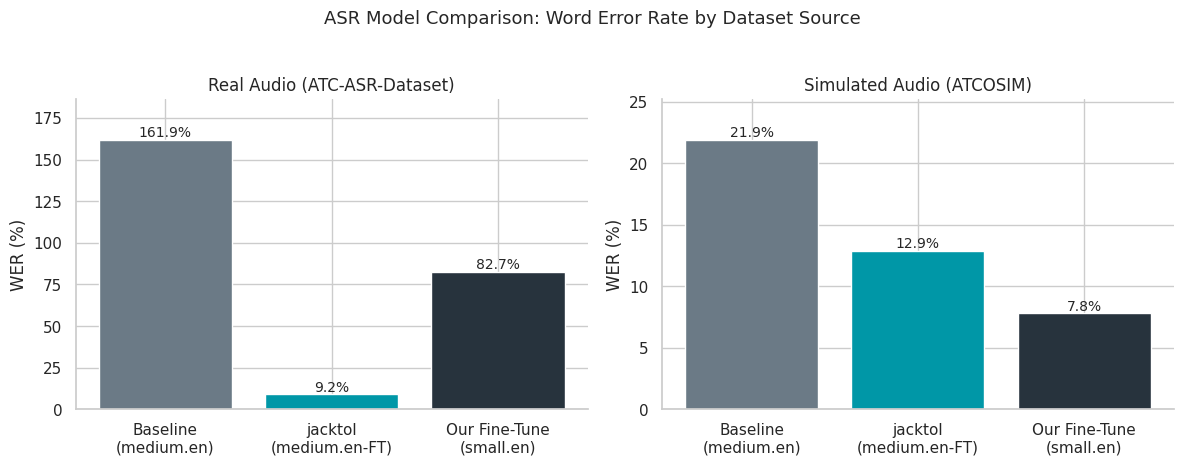

In [39]:
MODEL_ORDER = [BASELINE_MODEL_ID, COMPARISON_MODEL_ID, FINETUNE_MODEL_VERSION]
MODEL_LABELS = {
    BASELINE_MODEL_ID: "Baseline\n(medium.en)",
    COMPARISON_MODEL_ID: "jacktol\n(medium.en-FT)",
    FINETUNE_MODEL_VERSION: "Our Fine-Tune\n(small.en)",
}
MODEL_COLORS = {
    BASELINE_MODEL_ID: "#6B7A86",
    COMPARISON_MODEL_ID: "#0097A7",
    FINETUNE_MODEL_VERSION: "#27333D",
}
SOURCE_PANELS = [
    ("atc-asr-dataset", "Real Audio (ATC-ASR-Dataset)"),
    ("atcosim", "Simulated Audio (ATCOSIM)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (source, title) in zip(axes, SOURCE_PANELS):
    sub = (
        combined_summary[combined_summary["dataset_source"] == source]
        .set_index("model_version")
        .loc[MODEL_ORDER]
    )
    wer_pct = sub["wer"] * 100
    bars = ax.bar(
        [MODEL_LABELS[m] for m in MODEL_ORDER], wer_pct,
        color=[MODEL_COLORS[m] for m in MODEL_ORDER],
    )
    for bar, val in zip(bars, wer_pct):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10,
        )
    ax.set_title(title)
    ax.set_ylabel("WER (%)")
    ax.set_ylim(0, wer_pct.max() * 1.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("ASR Model Comparison: Word Error Rate by Dataset Source", y=1.03, fontsize=13)
fig.tight_layout()
save_fig(fig, "asr_model_comparison_wer")
plt.show()

**Observation:** We can see that with just 3 epochs on a small subset of the training data (1000 samples), we were able to improve the ASR performance with the small whisper model and surpass the ASR performance of the baseline medium whisper model, despite the small whisper model being a quarter of the size. However, it does **not** generalize to real audio anywhere near as well as jacktol's medium-sized fine-tuned whisper model (~83% vs. 9.2% WER). This is expected since the gap in model size and training data volume. On the other hand, the fine-tuned small whisper model does do better than jacktol's model on ATCOSIM (~7.5% vs. 12.9%). However, this isn't an apples-to-apples comparison. jacktol's model never saw ATCOSIM, while the fine-tuned small whisper model's stratified training subset *did* include ATCOSIM samples.

> **NOTE:** training re-runs introduce slight GPU non-determinism and the exact WER shifts by a few tenths of a point each time it's retrained, even with fixed seeds. jacktol's and the baseline's numbers come from fixed, pre-trained checkpoints doing pure inference, so those stay exactly the same run to run.

## D. Aviation-Specific Evaluation

> **NOTE:** neither corpus provides entity spans ground truth data so there's no labeled callsigns, commands, altitudes, etc. We'll have to rely on hardcoded callsign vocabulary for now until we can get such a ground truth dataset.

In [40]:
_CALLSIGN_VOCAB = ICAO_PHONETIC_ALPHABET | KNOWN_CALLSIGN_WORDS

print(f'Total words in callsign vocabulary: {len(_CALLSIGN_VOCAB)}')
print('='*60)
print(_CALLSIGN_VOCAB)

Total words in callsign vocabulary: 42
frozenset({'foxtrot', 'yankee', 'india', 'echo', 'juliet', 'whiskey', 'lufthansa', 'xray', 'sierra', 'britishairways', 'hansa', 'tango', 'golf', 'alitalia', 'zulu', 'charlie', 'papa', 'csa', 'shamrock', 'lima', 'oscar', 'juliett', 'november', 'luxair', 'klm', 'twinstar', 'romeo', 'bravo', 'belair', 'mike', 'airfrance', 'sabena', 'speedbird', 'victor', 'swissair', 'uniform', 'delta', 'kilo', 'alpha', 'crossair', 'quebec', 'hotel'})


In [41]:
print(f'Total words in numeric vocabulary: {len(ATC_NUMERAL_WORDS)}')
print('='*60)
print(ATC_NUMERAL_WORDS)

Total words in numeric vocabulary: 12
frozenset({'two', 'one', 'four', 'five', 'tree', 'six', 'seven', 'nine', 'eight', 'zero', 'niner', 'three'})


In [42]:
print(f'Total words in command vocabulary: {len(ATC_COMMAND_VERBS)}')
print('='*60)
print(ATC_COMMAND_VERBS)

Total words in command vocabulary: 19
frozenset({'land', 'hold', 'maintain', 'climb', 'established', 'contact', 'standby', 'report', 'resume', 'descend', 'taxi', 'cleared', 'proceed', 'turn', 'depart', 'cross', 'expect', 'squawk', 'identified'})


In [43]:
def token_recall(reference_norm: str, hypothesis_norm: str, vocab: frozenset):
    """Fraction of reference tokens in `vocab` that also appear in the
    hypothesis (bag-of-words recall, order-insensitive, proxy only).
    Returns None if the reference has zero matching tokens (the metric is
    undefined, not zero -- avoids silently penalizing utterances with
    nothing to find)."""
    ref_hits = [t for t in reference_norm.split() if t in vocab]
    if not ref_hits:
        return None
    hyp_tokens = set(hypothesis_norm.split())
    return sum(1 for t in ref_hits if t in hyp_tokens) / len(ref_hits)

combined_results["callsign_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], _CALLSIGN_VOCAB), axis=1)
combined_results["numeric_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], ATC_NUMERAL_WORDS), axis=1)
combined_results["command_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], ATC_COMMAND_VERBS), axis=1)

combined_results[["callsign_recall", "numeric_recall", "command_recall"]].describe()

,callsign_recall,numeric_recall,command_recall
count,135.000000,270.000000,201.000000
mean,0.716049,0.929156,0.890547
std,0.428307,0.198339,0.292336
min,0.000000,0.000000,0.000000
25%,0.266667,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


### Altitude / Heading / Runway / Frequency Accuracy

As mentioned previously, there's no ground truth data available for altitude, heading, runway, frequency, ect., so we'll have to take a pure rule-based regex approach for now.

In [44]:
_NUM_ALT = "one|two|three|four|five|six|seven|eight|nine|niner|zero"
_NUM = rf"(?:{_NUM_ALT})"

AVIATION_PATTERNS = {
    "frequency": re.compile(rf"\b{_NUM}(?: {_NUM}){{2,}}(?: decimal(?: {_NUM}){{1,3}})\b"),
    "runway": re.compile(rf"\brunway {_NUM}(?: {_NUM})?(?: left| right| center)?\b"),
    "heading": re.compile(rf"\bheading(?: {_NUM}){{3}}\b"),
    "altitude": re.compile(
        rf"\b(?:climb|descend|maintain)(?: to)?(?: (?:{_NUM_ALT}|flight|level|hundred|thousand))+\b"
    ),
}


def pattern_match_recall(reference_norm: str, hypothesis_norm: str, pattern: re.Pattern):
    """Presence proxy: does `pattern` (which fired on the reference) also
    fire somewhere in the hypothesis? None if the pattern never fired on the
    reference (nothing to check), matching `token_recall`'s convention."""
    if not pattern.search(reference_norm):
        return None
    return float(bool(pattern.search(hypothesis_norm)))


for name, pattern in AVIATION_PATTERNS.items():
    combined_results[f"{name}_present_recall"] = combined_results.apply(
        lambda r: pattern_match_recall(r["reference_norm"], r["hypothesis_norm"], pattern), axis=1)

combined_results[[f"{n}_present_recall" for n in AVIATION_PATTERNS]].describe()

,frequency_present_recall,runway_present_recall,heading_present_recall,altitude_present_recall
count,18.000000,30.000000,12.000000,66.000000
mean,0.888889,0.666667,0.916667,0.893939
std,0.323381,0.479463,0.288675,0.310275
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [45]:
proxy_cols = [
    "callsign_recall", "numeric_recall", "command_recall",
    "frequency_present_recall", "runway_present_recall",
    "heading_present_recall", "altitude_present_recall",
]
combined_results.groupby(["model_version", "dataset_source"])[proxy_cols].mean()

callsign_recall  \
model_version                                dataset_source                     
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset         0.970588   
                                             atcosim                 0.860714   
openai/whisper-medium.en                     atc-asr-dataset         0.103922   
                                             atcosim                 0.678571   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset         0.584314   
                                             atcosim                 0.905952   

                                                              numeric_recall  \
model_version                                dataset_source                    
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset        0.953063   
                                             atcosim                1.000000   
openai/whisper-medium.en                     atc-asr-dataset        0.698871   
                                             atcosim                0.971989   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset        0.894241   
                                             atcosim                1.000000   

                                                              command_recall  \
model_version                                dataset_source                    
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset        0.975000   
                                             atcosim                1.000000   
openai/whisper-medium.en                     atc-asr-dataset        0.500000   
                                             atcosim                0.914894   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset        0.625000   
                                             atcosim                1.000000   

                                                              frequency_present_recall  \
model_version                                dataset_source                              
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                       1.0   
                                             atcosim                               1.0   
openai/whisper-medium.en                     atc-asr-dataset                       0.0   
                                             atcosim                               0.8   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset                       1.0   
                                             atcosim                               1.0   

                                                              runway_present_recall  \
model_version                                dataset_source                           
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                    0.9   
                                             atcosim                            NaN   
openai/whisper-medium.en                     atc-asr-dataset                    0.6   
                                             atcosim                            NaN   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset                    0.5   
                                             atcosim                            NaN   

                                                              heading_present_recall  \
model_version                                dataset_source                            
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                     1.0   
                                             atcosim                             1.0   
openai/whisper-medium.en                     atc-asr-dataset                     1.0   
                                             atcosim                             1.0   
openai/whisper-small.en-finetuned-atc-subset atc-asr-dataset                     0.0   
                                             atcosim                             1.0   

        

### WER vs. Utterance Characteristics

Join eval results back to `utterance_df` by `utterance_id` to relate WER to acoustic/linguistic characteristics (addressing Research Question 3). 

> **NOTE:** `speech_rate_wpm` is unreliable under ~1 second of audio (e.g., dividing by a small denominator), so we masked it to `NaN` below that threshold. This is why we're seeing NaN values for `runway_present_recall` on the ATCOSIM dataset.

Saved figure: ../res/figures/wer_vs_utterance_characteristics.png


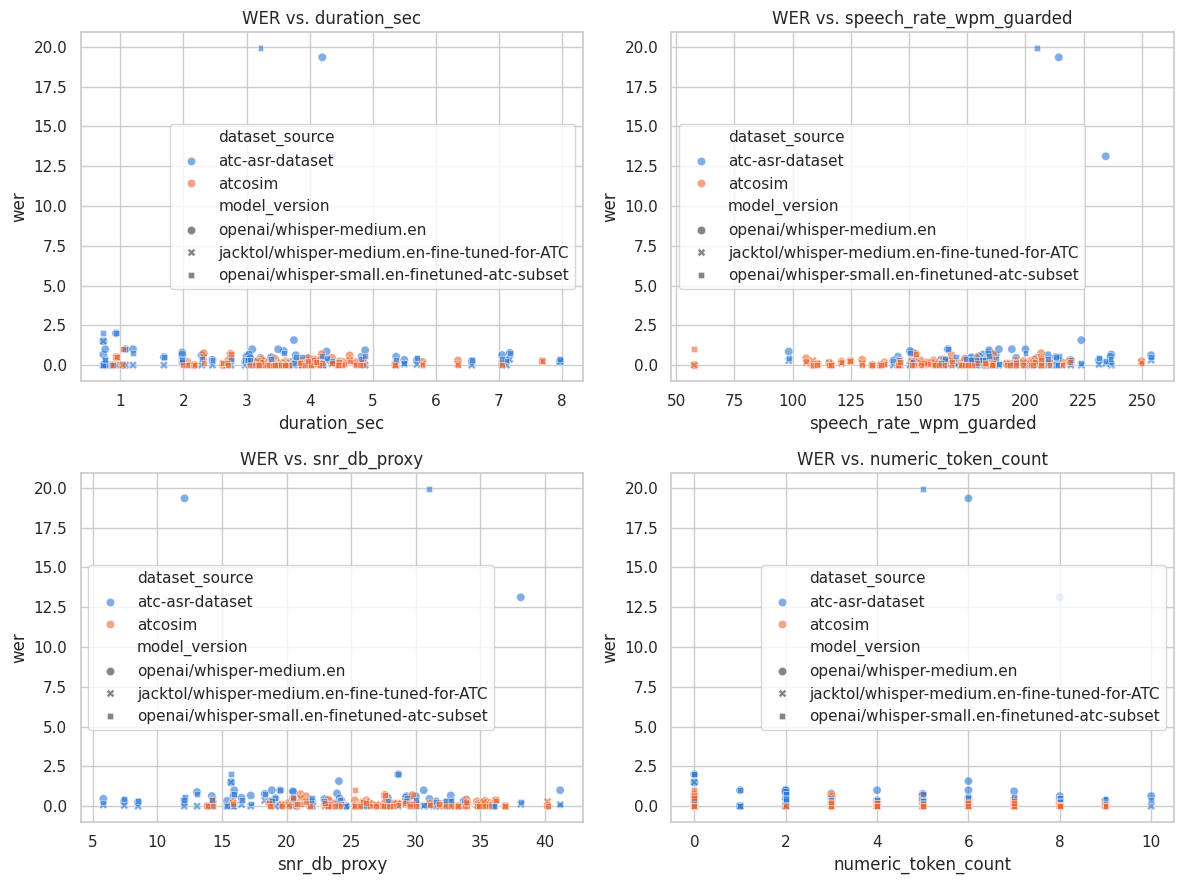

In [46]:
analysis_df = combined_results.merge(
    utterance_df[["utterance_id", "duration_sec", "speech_rate_wpm", "snr_db_proxy", "numeric_token_count"]],
    on="utterance_id", how="left",
)
analysis_df["speech_rate_wpm_guarded"] = analysis_df["speech_rate_wpm"].where(analysis_df["duration_sec"] >= 1.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, ["duration_sec", "speech_rate_wpm_guarded", "snr_db_proxy", "numeric_token_count"]):
    sns.scatterplot(
        data=analysis_df, x=col, y="wer", hue="dataset_source", hue_order=HUE_ORDER,
        palette=PALETTE, style="model_version", alpha=0.6, ax=ax,
    )
    ax.set_title(f"WER vs. {col}")
fig.tight_layout()
save_fig(fig, "wer_vs_utterance_characteristics")
plt.show()

### Does Lower WER Mean Better Aviation-Entity Recognition?

Word-level WER treats every token equally, but a single missed callsign or altitude digit matters far more operationally than a missed filler word. This checks whether low-WER utterances also score high on the proxy aviation-entity recall metrics, or whether there are counterexamples.

Saved figure: ../res/figures/wer_vs_callsign_recall.png


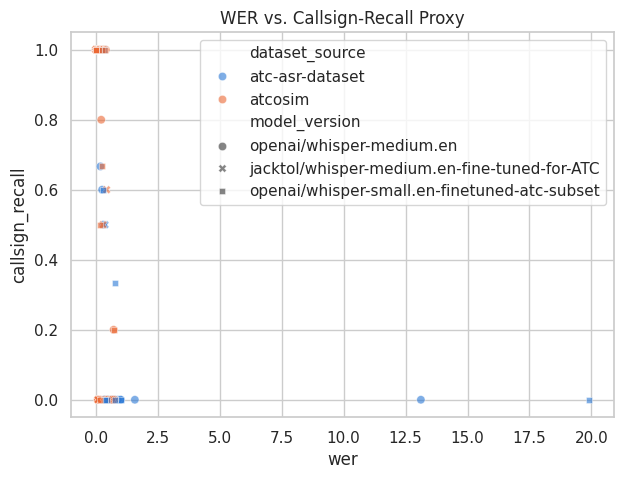

wer  \
model_version                                                            
jacktol/whisper-medium.en-fine-tuned-for-ATC wer              1.000000   
                                             callsign_recall -0.446433   
                                             numeric_recall  -0.147472   
                                             command_recall  -0.004637   
openai/whisper-medium.en                     wer              1.000000   
                                             callsign_recall -0.250083   
                                             numeric_recall  -0.459306   
                                             command_recall  -0.400473   
openai/whisper-small.en-finetuned-atc-subset wer              1.000000   
                                             callsign_recall -0.368626   
                                             numeric_recall  -0.547803   
                                             command_recall  -0.027330   

                                                              callsign_recall  \
model_version                                                                   
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                    -0.446433   
                                             callsign_recall         1.000000   
                                             numeric_recall         -0.124760   
                                             command_recall         -0.074720   
openai/whisper-medium.en                     wer                    -0.250083   
                                             callsign_recall         1.000000   
                                             numeric_recall          0.449816   
                                             command_recall          0.040331   
openai/whisper-small.en-finetuned-atc-subset wer                    -0.368626   
                                             callsign_recall         1.000000   
                                             numeric_recall          0.521770   
                                             command_recall          0.271138   

                                                              numeric_recall  \
model_version                                                                  
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                   -0.147472   
                                             callsign_recall       -0.124760   
                                             numeric_recall         1.000000   
                                             command_recall         0.303274   
openai/whisper-medium.en                     wer                   -0.459306   
                                             callsign_recall        0.449816   
                                             numeric_recall         1.000000   
                                             command_recall         0.280889   
openai/whisper-small.en-finetuned-atc-subset wer                   -0.547803   
                                             callsign_recall        0.521770   
                                             numeric_recall         1.000000   
                                             command_recall         0.130481   

                                                              command_recall  
model_version                                                                 
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                   -0.004637  
                                             callsign_recall       -0.074720  
                                             numeric_recall         0.303274  
                                             command_recall         1.000000  
openai/whisper-medium.en                     wer                   -0.400473  
                                             callsign_recall        0.040331  
                                             numeric_recall         0.280889  
                                             command_recall    

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=analysis_df, x="wer", y="callsign_recall", hue="dataset_source", hue_order=HUE_ORDER,
    palette=PALETTE, style="model_version", alpha=0.6, ax=ax,
)
ax.set_title("WER vs. Callsign-Recall Proxy")
save_fig(fig, "wer_vs_callsign_recall")
plt.show()

analysis_df.groupby("model_version")[["wer", "callsign_recall", "numeric_recall", "command_recall"]].corr()

**Observation:** The WER vs. recall correlations are moderate and mostly negative. For `openai/whisper-medium.en`, corr(wer, callsign_recall) = -0.25, corr(wer, numeric_recall) = -0.46, and corr(wer, command_recall) = -0.40; for `jacktol/whisper-medium.en-fine-tuned-for-ATC`, corr(wer, callsign_recall) = -0.45; for our own fine-tuned `openai/whisper-small.en`, corr(wer, callsign_recall) ≈ -0.34, corr(wer, numeric_recall) ≈ -0.50, and corr(wer, command_recall) ≈ -0.04 (essentially no relationship). This tells us that the WER signal is not complete. For example, two utterances can have nearly the same WER but differ significantly in whether a specific callsign was correctly recognized or not. Our fine-tune's near-zero command_recall correlation is a good illustration of this: its overall WER barely moves with whether a command verb survives, so a report that only tracked aggregate WER could easily miss that its command recognition is meaningfully worse than its WER alone would suggest.

Introducing this domain gap makes this really clear when we look at the source breakdown. The baseline whisper-medium model's `callsign_recall` drops from **67.9%** on ATCOSIM to just **10.4%** on real ATC-ASR-Dataset audio. This is a much bigger collapse than the aggregate WER numbers (22% -> 162%) would suggest. The `jacktol` fine-tuned/domain-adapted whisper-medium comparison model holds up a lot better across sources (**86.1%** ATCOSIM vs. **97.1%** ATC-ASR-Dataset, but there could be a training data leakage problem with the dataset it used for training). Our own fine-tuned `whisper-small.en` lands in between the two: callsign_recall drops from **~87%** on ATCOSIM to **~57%** on real audio, roughly half the baseline's collapse but still a real domain gap, consistent with training on far less data than jacktol's checkpoint.

## Error Taxonomy
We need to justify the high corpus-level WER. To do so, we'll inspect the worst WER samples and inspect what's really going on.

In [48]:
def describe_alignment(reference_norm: str, hypothesis_norm: str):
    """Word-level alignment for one utterance, resolved to actual
    ref/hyp word spans (jiwer.process_words's own .substitutions/.deletions/
    .insertions are integer counts, not the words themselves -- the words
    live in .alignments, resolved here against .references/.hypotheses)."""
    result = jiwer.process_words(reference_norm, hypothesis_norm)
    ref_words, hyp_words = result.references[0], result.hypotheses[0]
    subs, dels, ins = [], [], []
    for chunk in result.alignments[0]:
        if chunk.type == "substitute":
            subs.append((ref_words[chunk.ref_start_idx:chunk.ref_end_idx],
                         hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx]))
        elif chunk.type == "delete":
            dels.append(ref_words[chunk.ref_start_idx:chunk.ref_end_idx])
        elif chunk.type == "insert":
            ins.append(hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx])
    return subs, dels, ins


worst_rows = (
    combined_results.sort_values("wer", ascending=False)
    .groupby("model_version")
    .head(10)
)
for _, row in worst_rows.iterrows():
    subs, dels, ins = describe_alignment(row["reference_norm"], row["hypothesis_norm"])
    print(f"{row['model_version']} | {row['utterance_id']} | wer={row['wer']:.2f}")
    print(" ref:", row["reference_norm"])
    print(" hyp:", row["hypothesis_norm"])
    print(" substitutions:", subs)
    print(" deletions:", dels)
    print(" insertions:", ins)
    print()

openai/whisper-small.en-finetuned-atc-subset | atc-asr-dataset-test-000445 | wer=19.91
 ref: cleared to land runway three one swiss one two four bravo
 hyp: praha cleared to land runway three run to flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight flight fli

**Observation:** We can see now that the corpus-level aggregate 162% WER is heavily skewed by two catastrophic outliers (`atc-asr-dataset-test-000294` and `atc-asr-dataset-test-000352`). Both outliers are repetition-loop hallucinations. The *median* per-utterance WER on the real-audio subset is actually 56%, which is still clearly worse than ATCOSIM but far less dramatic than the mean (162%) suggests. This is a good reminder that corpus-level WER can be misleading when a small number of runaway outputs dominate the aggregate mean. This is why the per-utterance error taxonomy is worth looking at alongside the aggregate mean.

The custom fine-tuned `whisper-small.en` shows the identical pattern on the real audio outputs, showing an aggregate WER of ~83% versus a *median* of only ~35%. The aggregate WER is driven by a single repetition-loop outlier (see `atc-asr-dataset-test-000445`, which is just the word "flight" repeated ~215 times). This shows that fine-tuning clearly helped overall accuracy, but there's still the Whisper "bug" that causes repeated classification outputs. This is a known architectural/decoding quirk with Whisper models that fine-tuning won't be able to fix. Thus, we'll have to implement a way to catch and address this classification edge case with Whisper models (e.g., hyperparameter tuning, filtering, etc.). See https://metawhisp.com/blog/whisper-repeating-word-loop-fix/ and https://arxiv.org/pdf/2212.04356

**Taxonomy:**

| Category | Description | Example `utterance_id` |
| --- | --- | --- |
| Repetition-loop hallucination | Whisper's beam search gets stuck repeating a short phrase dozens (or hundreds) of times on short/low-information or noisy audio. This is a known Whisper failure mode that persists even after fine-tuning. Dominates the real-audio aggregate WER for both the baseline and our fine-tune. | `atc-asr-dataset-test-000294` (baseline: "good morning" x~150), `atc-asr-dataset-test-000352` (baseline: "r" x~150), `atc-asr-dataset-test-000445` (our fine-tune: "flight" x~215) |
| Numeral substitution / "nine" vs. "niner" | Caused by the disclosed normalizer gap from Section A: `expand_digits_to_atc_words` always emits "nine", so a reference "niner" mismatches a correct-sounding hypothesis "nine" | `atc-asr-dataset-test-000589` (comparison: ref "niner" -> hyp "nine") |
| Callsign misrecognition | An airline/place-name word substituted for a similar-sounding but wrong one, or (for the smaller fine-tuned model) a phonetic-alphabet callsign garbled into unrelated-sounding words | `atcosim-validation-000979` (baseline: "algerie" -> "jerry"), `atcosim-train-000676` (baseline: "sabena" -> "sabina", "rhein" -> "line"), `atc-asr-dataset-test-000198` (our fine-tune: "eight juliett echo" -> "athria degol") |
| Short-word / sign-off deletion | A trailing acknowledgement or sign-off word dropped entirely | `atcosim-train-003697` (comparison: "tschuss" deleted) |
| Homophone confusion | A word substituted for one that sounds identical or near-identical but changes meaning/spelling | `atcosim-train-000664` (baseline: "rhein" -> "rhine"), `atcosim-train-003601` (baseline: "four" -> "for") |

## E. NER Dataset Curation (LLM-Assisted)

Section D could only *proxy* aviation-entity quality because neither corpus ships entity spans. The end goal is a fast spaCy and/or BERT NER model for the Streamlit app, since an LLM is far too slow at inference time. Here we prototype the **dataset-building step**. Because the final model is only as good as its labels, the emphasis is on **annotation validity**, measured against a small hand-labeled gold set:

1. **Filter** the corpus: single-word utterances and utterances that are only greeting/farewell/filler ("bye bye", "thank you", "roger") are excluded from the dataset.
2. A Qwen 3.5 instruct model annotates reference transcripts by calling a pydantic-validated `add_entity` tool.
3. **Per-label constraints** (e.g. RUNWAY must contain the word "runway", greetings are never entities) are checked on every call. Violations go back to the model as tool errors so it can fix them.
4. **Rule-based hints**: regex/vocabulary candidates (Section D patterns, extended) are shown to the LLM as *unverified* suggestions.
5. An **ablation on the gold set** compares model size and each of the above, so we pick the annotator by measured span-level F1 rather than by impression.
6. **Targeted sampling** oversamples utterances with cues for rare labels (squawk, waypoint, runway, heading), which a uniform sample barely contains.
7. **Review routing**: a second annotator plus cheap consistency checks flag utterances whose labels are doubtful. Flagged utterances are quarantined from the training data instead of being trusted. The gold set measures whether the routing actually raises label validity.
8. Export `DocBin` (spaCy) and IOB2 JSONL (BERT) with the existing train/validation/test splits, using hand-labeled gold spans wherever we have them. Smoke-test by training a blank spaCy NER.

> **NOTE:** this is a prototype on a small sample (`N_NER_SAMPLES`). The same logic will move into a standalone pipeline script later.

In [49]:
import gc
import hashlib
import json
import random
import time
from collections import Counter
from typing import Literal

import spacy
from datasets import load_dataset
from pydantic import BaseModel, ValidationError, field_validator
from spacy.tokens import DocBin
from spacy.training import Example
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

from preprocessing.vocab import ATC_COMMAND_VERBS, KNOWN_CALLSIGN_WORDS

# Annotator used for the production run below (chosen from the ablation results).
NER_MODEL_ID = "Qwen/Qwen3.5-4B"
NER_LOAD_IN_4BIT = True   # 4-bit (bitsandbytes) lets a larger model fit the 6 GB GPU
NER_USE_CONSTRAINTS = True
NER_USE_HINTS = True

# Second annotator, used only for agreement-based review routing.
NER_SECOND_MODEL_ID = "Qwen/Qwen3.5-2B"
NER_SECOND_LOAD_IN_4BIT = False
NER_EXCLUDE_NEEDS_REVIEW = True  # quarantine doubtful utterances from the exported training data

# Bump when check_constraints / rule_candidates change, so cached annotations and ablation rows are not reused.
RULES_VERSION = "2"

# Scale toggle: small stratified sample while prototyping; None = full corpus.
# The hand-labeled gold utterances are always included in the sample.
N_NER_SAMPLES = 500
N_TARGETED_PER_LABEL = 40  # extra utterances per rare-label cue (SQUAWK, WAYPOINT, RUNWAY, HEADING)

NER_MAX_TURNS = 3         # generate -> validate -> feed errors back, at most this many rounds
NER_MAX_NEW_TOKENS = 256

NER_DIR = os.path.join(os.getcwd(), "..", "data", "processed", "ner_dataset")
NER_ABLATION_PATH = os.path.join(NER_DIR, "ablation_results.json")
NER_GOLD_PATH = os.path.join(os.getcwd(), "..", "data", "ner_gold", "gold.jsonl")  # hand-labeled, tracked
os.makedirs(NER_DIR, exist_ok=True)

### Label Schema, Constraints and Span Alignment

`EntitySpan` is the structure the LLM must build. Training data needs *character offsets*, so `align_entities` maps each entity back onto the transcript and rejects anything not found verbatim on a word boundary or overlapping an earlier entity. `check_constraints` adds per-label validity rules. Its error messages are written as fix-it instructions because they are shown to the LLM. This is the main quality gate: a hallucinated, paraphrased or mislabeled span is rejected instead of silently entering the training data.

`GREETING_PHRASES` came from corpus counts (e.g. "bye" ~1,800 utterances, "roger" ~750). `is_trainable_utterance` implements the dataset filter.

**Annotation guidelines** (used for both the prompt and the gold set): spans are minimal; `COMMAND` is the instruction verb only, never its numbers or destination; a station name (`FACILITY`) is separate from its `FREQUENCY`; greetings, farewells and filler are never labeled.

In [50]:
NerLabel = Literal[
    "CALLSIGN", "RUNWAY", "ALTITUDE", "HEADING", "FREQUENCY",
    "SQUAWK", "COMMAND", "WAYPOINT", "FACILITY",
]

NER_LABELS = {
    "CALLSIGN": "aircraft callsign: airline/telephony word plus spoken digits/letters, or a registration spelled phonetically (e.g. 'lufthansa four one alpha', 'delta india kilo alpha hotel')",
    "RUNWAY": "runway designator including side if given (e.g. 'runway two four left')",
    "ALTITUDE": "altitude or flight level with its numbers, without the verb (e.g. 'flight level three one zero', 'four thousand feet')",
    "HEADING": "compass heading with its digits (e.g. 'heading two seven zero')",
    "FREQUENCY": "radio frequency digits only, starting at the first digit word (e.g. 'one three three decimal four'); the station name is a separate FACILITY",
    "SQUAWK": "transponder code (e.g. 'squawk four two one zero')",
    "COMMAND": "controller instruction verb (phrase) only, never its numbers or destination (e.g. 'descend', 'contact', 'turn left', 'cleared to land', 'set course')",
    "WAYPOINT": "named fix, waypoint, navaid or place used as a navigation target (e.g. 'vemut', 'karlsruhe')",
    "FACILITY": "ATC facility or station name, without any digits (e.g. 'praha', 'rhein', 'zurich radar', 'tower')",
}
assert set(NER_LABELS) == set(NerLabel.__args__)

DIGIT_WORDS = frozenset({"zero", "one", "two", "three", "tree", "four", "five", "fife", "six",
                         "seven", "eight", "nine", "niner", "triple", "double"})
NUMBER_WORDS = DIGIT_WORDS | {"hundred", "thousand"}
PHONETIC_WORDS = frozenset({
    "alpha", "alfa", "bravo", "charlie", "delta", "echo", "foxtrot", "golf", "hotel", "india",
    "juliet", "juliett", "kilo", "lima", "mike", "november", "oscar", "papa", "quebec", "romeo",
    "sierra", "tango", "uniform", "victor", "whiskey", "xray", "yankee", "zulu",
})

GREETING_PHRASES = (
    "good afternoon", "good morning", "good evening", "good day", "good night",
    "good bye", "goodbye", "bye bye", "bye", "hello", "guten tag", "tschuss",
    "servus", "bonjour", "adios", "adieu", "ciao", "thank you", "thanks",
    "roger", "okay", "ok", "ah", "uh", "oh", "yes", "sir",
)
_GREETING_RE = re.compile(
    r"(?<!\S)(?:" + "|".join(sorted(map(re.escape, GREETING_PHRASES), key=len, reverse=True)) + r")(?!\S)"
)


def strip_greetings(text: str) -> str:
    """`text` with greeting/farewell/filler phrases removed, whitespace collapsed."""
    return " ".join(_GREETING_RE.sub(" ", text).split())


def is_trainable_utterance(text: str) -> bool:
    """False for single-word utterances and ones that are only greeting/filler."""
    return len(text.split()) >= 2 and bool(strip_greetings(text))


class EntitySpan(BaseModel):
    """One entity the LLM wants to record. `text` must be copied verbatim from the utterance."""
    text: str
    label: NerLabel

    @field_validator("text")
    @classmethod
    def _normalize_text(cls, v: str) -> str:
        v = " ".join(v.lower().split())
        if not v:
            raise ValueError("entity text must not be empty")
        return v


class AnnotatedUtterance(BaseModel):
    utterance_id: str
    text: str
    entities: list[EntitySpan]
    n_turns: int
    n_rejected: int
    ok: bool
    latency_s: float


ALTITUDE_UNITS = frozenset({"level", "feet", "foot", "thousand", "hundred", "altitude", "metres", "meters"})
PROCEDURE_WORDS = frozenset({"ils", "localizer", "approach", "runway", "glideslope", "departure", "arrival"})


def check_constraints(ent: EntitySpan, text: str | None = None) -> None:
    """Raise ValueError (with a fix-it message for the LLM) if `ent` breaks a label rule.

    `text` (the full utterance) enables context rules, e.g. a number after 'speed'."""
    toks = ent.text.split()
    has_num = any(t in NUMBER_WORDS for t in toks)
    if "knots" in toks or "knot" in toks:
        raise ValueError("speeds ('... knots') are not entities; do not label them")
    if not strip_greetings(ent.text):
        raise ValueError(f"'{ent.text}' is a greeting/farewell/filler word, not an entity; do not label it")
    if ent.label == "CALLSIGN":
        if toks[0] in {"and", "roger", "ok", "okay", "hello", "oh", "yes", "request", "radar"}:
            raise ValueError(f"callsign must not start with '{toks[0]}'; start at the airline name or first letter/digit")
        if all(t in DIGIT_WORDS for t in toks):
            raise ValueError("a callsign needs an airline name or phonetic letters, not only digits")
    elif ent.label == "RUNWAY":
        if "runway" not in toks or not has_num:
            raise ValueError("RUNWAY must contain the word 'runway' and its number")
    elif ent.label == "HEADING":
        if "heading" not in toks or not has_num:
            raise ValueError("HEADING must contain the word 'heading' and its number")
    elif ent.label == "SQUAWK":
        if "squawk" not in toks or not has_num:
            raise ValueError("SQUAWK must contain the word 'squawk' and its code")
    elif ent.label == "ALTITUDE":
        if not has_num or not ALTITUDE_UNITS & set(toks):
            raise ValueError("ALTITUDE must contain its number and 'level', 'feet', 'thousand' or 'hundred' (e.g. 'flight level three one zero')")
        if toks[0] in {"climb", "descend", "maintain", "climbing", "descending", "to", "at", "on"}:
            raise ValueError(f"ALTITUDE must not start with '{toks[0]}'; the verb is a separate COMMAND")
    elif ent.label == "FREQUENCY":
        if toks[0] not in NUMBER_WORDS:
            raise ValueError("FREQUENCY must start at the first digit word; label the station name FACILITY and drop words like 'on'")
        if "decimal" not in toks and sum(t in DIGIT_WORDS for t in toks) < 4:
            raise ValueError("FREQUENCY needs 'decimal' or at least four digits; a short number is not a frequency")
        if text and re.search(rf"(?<!\S)(?:speed|mach) {re.escape(ent.text)}(?!\S)", text):
            raise ValueError("that number follows 'speed', so it is a speed, not a frequency")
    elif ent.label == "COMMAND":
        if has_num or len(toks) > 4:
            raise ValueError("COMMAND is the instruction verb phrase only (max 4 words, no numbers); label numbers and places separately")
    elif ent.label in {"WAYPOINT", "FACILITY"}:
        if has_num:
            raise ValueError(f"{ent.label} must not include digits; a frequency or code is its own entity")
        if ent.label == "WAYPOINT" and PROCEDURE_WORDS & set(toks):
            raise ValueError("ILS/localizer/approach/runway words describe a procedure, not a waypoint")


def align_entities(text: str, entities: list[EntitySpan]):
    """Map entities onto `text` as (start, end, label) character spans.

    Each entity takes the first not-yet-used whole-word occurrence, left to
    right. Returns (aligned spans sorted by start, [(entity, reason), ...])."""
    aligned, rejected = [], []
    for ent in entities:
        pattern = re.compile(rf"(?<!\S){re.escape(ent.text)}(?!\S)")
        matches = list(pattern.finditer(text))
        free = [m for m in matches if not any(m.start() < e and s < m.end() for s, e, _ in aligned)]
        if not matches:
            rejected.append((ent, f"'{ent.text}' does not appear verbatim (on word boundaries) in the utterance"))
        elif not free:
            rejected.append((ent, f"'{ent.text}' only occurs inside text already labeled by another entity"))
        else:
            aligned.append((free[0].start(), free[0].end(), ent.label))
    return sorted(aligned), rejected


def entity_spans(text: str, entities: list[dict]) -> list[tuple[int, int, str]]:
    """(start, end, label) character spans for entity dicts, end exclusive.

    Uses each entity's explicit `"span": [start, end]` when every entity has one
    (checked against `text`); otherwise falls back to `align_entities`."""
    if entities and all("span" in e for e in entities):
        spans = []
        for e in entities:
            start, end = e["span"]
            if not (0 <= start < end <= len(text)) or text[start:end] != e["text"]:
                raise ValueError(f"span {e['span']} does not match {e['text']!r} in {text!r}")
            spans.append((start, end, e["label"]))
        return sorted(spans)
    return align_entities(text, [EntitySpan(**e) for e in entities])[0]


def with_spans(text: str, entities: list[dict]) -> list[dict]:
    """Entity dicts in reading order, each carrying its explicit `span` offsets."""
    return [{"text": text[s:e], "label": l, "span": [s, e]} for s, e, l in entity_spans(text, entities)]


# Sanity checks
_t = "lufthansa four one alpha descend flight level one two zero"
_a, _r = align_entities(_t, [EntitySpan(text="Lufthansa four one alpha", label="CALLSIGN"),
                             EntitySpan(text="flight level one two zero", label="ALTITUDE"),
                             EntitySpan(text="descend to", label="COMMAND"),
                             EntitySpan(text="four one", label="ALTITUDE")])
assert [(_t[s:e], l) for s, e, l in _a] == [("lufthansa four one alpha", "CALLSIGN"), ("flight level one two zero", "ALTITUDE")]
assert len(_r) == 2
for _bad in [EntitySpan(text="good day", label="COMMAND"), EntitySpan(text="rhein one three two decimal four", label="FACILITY"),
             EntitySpan(text="on one three three decimal four", label="FREQUENCY"), EntitySpan(text="six seven zero", label="CALLSIGN"),
             EntitySpan(text="runway", label="RUNWAY"), EntitySpan(text="one eight zero", label="FREQUENCY"),
             EntitySpan(text="ils approach", label="WAYPOINT"), EntitySpan(text="speed two fifty", label="ALTITUDE"),
             EntitySpan(text="one eight zero knots", label="ALTITUDE")]:
    try:
        check_constraints(_bad)
        raise AssertionError(f"constraint should have rejected {_bad}")
    except ValueError:
        pass
_e = with_spans(_t, [{"text": "descend", "label": "COMMAND"}, {"text": "lufthansa four one alpha", "label": "CALLSIGN"}])
assert _e == [{"text": "lufthansa four one alpha", "label": "CALLSIGN", "span": [0, 24]},
              {"text": "descend", "label": "COMMAND", "span": [25, 32]}]
try:
    entity_spans(_t, [{"text": "descend", "label": "COMMAND", "span": [0, 7]}])
    raise AssertionError("a wrong span must be rejected")
except ValueError:
    pass
try:
    check_constraints(EntitySpan(text="one eight zero", label="FREQUENCY"), "speed one eight zero")
    raise AssertionError("a number after 'speed' must be rejected")
except ValueError:
    pass
assert [is_trainable_utterance(x) for x in ["roger", "thank you", "standby", "ah stand by", "roger turn left"]] == [False, False, False, True, True]
print("schema checks OK")

schema checks OK


### Rule-Based Hints

The Section D regexes and vocabularies, extended (squawk, a tighter altitude pattern, callsign runs, facility words), become *candidate spans* that are shown to the LLM as **unverified hints**. They are deliberately high-recall and imprecise (for example a bare digit run such as "wind two three zero" looks like a callsign), so the prompt tells the model to verify each one and not to treat the list as complete.

`FACILITY_WORDS` was chosen from corpus counts (the most common words after "contact", plus the radar/tower/approach/control/ground/information/apron roles). It is a weak hint, not a gazetteer.

In [51]:
_N = "(?:" + "|".join(sorted(DIGIT_WORDS, key=len, reverse=True)) + ")"
RULE_PATTERNS = {
    "FREQUENCY": re.compile(rf"\b{_N}(?: {_N}){{1,3}} decimal(?: {_N}){{1,3}}\b"),
    "RUNWAY": re.compile(rf"\brunway {_N}(?: {_N})?(?: left| right| center)?\b"),
    "HEADING": re.compile(rf"\bheading (?:of )?(?:{_N}(?: {_N}){{2}}|{_N} hundred|three hundred)\b"),
    "ALTITUDE": re.compile(rf"\b(?:flight level|level)(?: {_N}){{2,3}}\b|\b(?:{_N} )+(?:thousand|hundred)(?: feet)?\b"),
    "SQUAWK": re.compile(rf"\bsquawk(?: {_N}){{4}}\b"),
}
FACILITY_WORDS = frozenset({
    "radar", "tower", "approach", "control", "ground", "information", "apron",
    "zurich", "rhein", "milan", "geneva", "praha", "bratislava", "ruzyne",
})
_CALLSIGN_TOKEN = DIGIT_WORDS | PHONETIC_WORDS


def _overlap(a, b) -> bool:
    return a[0] < b[1] and b[0] < a[1]


def rule_candidates(text: str) -> list[tuple[str, str]]:
    """Candidate (label, text) pairs from regex/vocabulary rules, in text order."""
    found = [(m.start(), m.end(), label)
             for label, pat in RULE_PATTERNS.items() for m in pat.finditer(text)]
    toks = [(m.group(), m.start(), m.end()) for m in re.finditer(r"\S+", text)]
    i = 0
    while i < len(toks):  # callsign: a known call-word + following digit/letter run, or a long bare run
        word, s, _ = toks[i]
        j = i + 1 if word in KNOWN_CALLSIGN_WORDS else i
        while j < len(toks) and toks[j][0] in _CALLSIGN_TOKEN:
            j += 1
        run = j - i
        if j > i and ((word in KNOWN_CALLSIGN_WORDS and run >= 2) or (word not in KNOWN_CALLSIGN_WORDS and run >= 3)):
            span = (s, toks[j - 1][2], "CALLSIGN")
            if not any(_overlap(span, f) for f in found):
                found.append(span)
        i = max(j, i + 1)
    for w, s, e in toks:
        label = "COMMAND" if w in ATC_COMMAND_VERBS else "FACILITY" if w in FACILITY_WORDS else None
        if label and not any(_overlap((s, e), f) for f in found):
            found.append((s, e, label))
    return [(label, text[s:e]) for s, e, label in sorted(found)]


assert ("FREQUENCY", "one three three decimal four") in rule_candidates("contact zurich one three three decimal four")
assert ("FACILITY", "zurich") in rule_candidates("contact zurich one three three decimal four")
print(rule_candidates("sabena eight zero six climb flight level three four zero contact rhein one three two decimal four"))

[('CALLSIGN', 'sabena eight zero six'), ('COMMAND', 'climb'), ('ALTITUDE', 'flight level three four zero'), ('COMMAND', 'contact'), ('FACILITY', 'rhein'), ('FREQUENCY', 'one three two decimal four')]


### Tool Calling Loop

The model is given one tool, `add_entity`, whose JSON schema is generated straight from `EntitySpan`. Qwen 3.5 emits calls in an XML-like format (`<tool_call><function=...><parameter=...>`), which `parse_tool_calls` converts to dicts. Without constrained decoding (no vLLM here), validity is enforced by pydantic, `check_constraints` and `align_entities`. Rejected calls are returned to the model as tool messages so it can correct itself, up to `NER_MAX_TURNS`. If every call in a turn is accepted we stop without another generation, which saves a full LLM pass per utterance.

`annotate_utterance` takes `use_constraints` and `use_hints` switches so the ablation below can measure each one separately.

In [52]:
SYSTEM_PROMPT = (
    "You annotate air traffic control (ATC) radio transcripts for named-entity recognition. "
    "The transcript is lowercase with numbers spelled out as words. For every entity, call the "
    "add_entity tool once, copying the entity text EXACTLY and contiguously from the transcript. "
    "Use the shortest correct span. Do not paraphrase, do not merge separate entities, and do not "
    "label greetings, farewells or filler (good afternoon, good day, bye, tschuss, thank you, roger, ah). "
    "If there are no entities, make no tool calls.\n\n"
    "Labels:\n" + "\n".join(f"- {k}: {v}" for k, v in NER_LABELS.items()) + "\n\n"
    "Examples:\n"
    "Transcript: lufthansa four one alpha descend flight level one two zero\n"
    "Entities: CALLSIGN 'lufthansa four one alpha'; COMMAND 'descend'; ALTITUDE 'flight level one two zero'\n"
    "Transcript: praha good evening csa five mike bravo contact zurich one three three decimal four\n"
    "Entities: FACILITY 'praha'; CALLSIGN 'csa five mike bravo'; COMMAND 'contact'; FACILITY 'zurich'; FREQUENCY 'one three three decimal four'\n"
    "Transcript: ah stand by\n"
    "Entities: COMMAND 'stand by'\n"
    "Transcript: good evening speedbird two seven heading two seven zero squawk four two one zero runway two four left\n"
    "Entities: CALLSIGN 'speedbird two seven'; HEADING 'heading two seven zero'; SQUAWK 'squawk four two one zero'; RUNWAY 'runway two four left'"
)

_ENTITY_SCHEMA = EntitySpan.model_json_schema()
_ENTITY_SCHEMA.pop("title", None)
NER_TOOLS = [{
    "type": "function",
    "function": {
        "name": "add_entity",
        "description": "Record one entity span, copied verbatim from the transcript.",
        "parameters": _ENTITY_SCHEMA,
    },
}]

_CALL_RE = re.compile(r"<function=(\w+)>(.*?)</function>", re.S)
_PARAM_RE = re.compile(r"<parameter=(\w+)>\s*(.*?)\s*</parameter>", re.S)


def parse_tool_calls(generated: str) -> list[tuple[str, dict]]:
    """Parse Qwen 3.5's XML-style tool calls into [(function_name, {param: value})]."""
    generated = generated.split("<|im_end|>")[0]
    return [(name, dict(_PARAM_RE.findall(body))) for name, body in _CALL_RE.findall(generated)]


def build_user_message(text: str, use_hints: bool) -> str:
    msg = f"Transcript: {text}"
    if use_hints:
        hint = "; ".join(f"{label} '{t}'" for label, t in rule_candidates(text)) or "none found"
        msg += ("\n\nPattern-matcher candidates (unverified: the list is INCOMPLETE and may contain wrong or "
                "mislabeled items. Verify each one, drop the wrong ones, and also annotate any entities it "
                f"missed, especially facility names, waypoints and commands): {hint}")
    return msg


@torch.no_grad()
def _generate(model, tokenizer, messages) -> str:
    inputs = tokenizer.apply_chat_template(
        messages, tools=NER_TOOLS, add_generation_prompt=True, return_tensors="pt",
        return_dict=True, enable_thinking=False,
    ).to(model.device)
    out = model.generate(**inputs, max_new_tokens=NER_MAX_NEW_TOKENS, do_sample=False)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)


def annotate_utterance(model, tokenizer, utterance_id: str, text: str, *,
                       use_constraints: bool = True, use_hints: bool = True) -> AnnotatedUtterance:
    """Run the validate-and-retry tool loop for one transcript."""
    start = time.perf_counter()
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": build_user_message(text, use_hints)}]
    accepted: list[EntitySpan] = []
    n_rejected, n_turns, ok = 0, 0, True

    for _ in range(NER_MAX_TURNS):
        n_turns += 1
        calls = parse_tool_calls(_generate(model, tokenizer, messages))
        if not calls:
            ok = True
            break
        results, turn_rejections = [], 0
        for name, args in calls:
            try:
                if name != "add_entity":
                    raise ValueError(f"unknown tool '{name}'; only add_entity exists")
                ent = EntitySpan(**args)
                if use_constraints:
                    check_constraints(ent, text)
                _, rejected = align_entities(text, accepted + [ent])
                if rejected:
                    raise ValueError(rejected[-1][1])
                accepted.append(ent)
                results.append(f"ok: recorded {ent.label} '{ent.text}'")
            except (ValidationError, ValueError, TypeError) as exc:
                turn_rejections += 1
                results.append(f"error: {str(exc).splitlines()[0]}")
        n_rejected += turn_rejections
        ok = turn_rejections == 0
        if ok:
            break
        messages.append({"role": "assistant", "content": "", "tool_calls": [
            {"type": "function", "function": {"name": n, "arguments": a}} for n, a in calls]})
        messages.extend({"role": "tool", "content": r} for r in results)

    return AnnotatedUtterance(
        utterance_id=utterance_id, text=text, entities=accepted, n_turns=n_turns,
        n_rejected=n_rejected, ok=ok, latency_s=round(time.perf_counter() - start, 3),
    )


def load_annotator(model_id: str, load_in_4bit: bool = False):
    """Load an annotator LLM; 4-bit (nf4) lets a ~4B model fit the 6 GB GPU."""
    gc.collect(); torch.cuda.empty_cache()  # free any leftover model first
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    kwargs = ({"quantization_config": BitsAndBytesConfig(
                   load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16)}
              if load_in_4bit else {"dtype": torch.bfloat16})
    model = AutoModelForCausalLM.from_pretrained(model_id, device_map=DEVICE, **kwargs).eval()
    print(f"Loaded {model_id} ({'4-bit' if load_in_4bit else 'bf16'}); GPU memory in use: {torch.cuda.memory_allocated() / 1e9:.1f} GB")
    return model, tokenizer


_raw = ("<tool_call>\n<function=add_entity>\n<parameter=text>\nflight level one two zero\n</parameter>\n"
        "<parameter=label>\nALTITUDE\n</parameter>\n</function>\n</tool_call><|im_end|>")
assert parse_tool_calls(_raw) == [("add_entity", {"text": "flight level one two zero", "label": "ALTITUDE"})]
print("parse_tool_calls OK")

parse_tool_calls OK


### Gold Set and Span-Level Scoring

`data/ner_gold/gold.jsonl` holds 41 validation/test utterances (120 spans) **hand-labeled following the guidelines above**. Three ambiguous utterances were left out rather than guessed (a bare airport-code-like "echo delta delta tango", "zurich one three three four", and the one-word "standby"). These are the same utterances that fall into the dev/test splits, so they double as trustworthy evaluation data.

`score_spans` is exact-match precision/recall/F1 on `(start, end, label)`. A missed span is costly for training data because it becomes a false "O" tag, so recall matters as much as precision.

Each gold entity carries explicit character offsets, e.g. `{"text": "flight level one four zero", "label": "ALTITUDE", "span": [41, 67]}`. `span` is `[start, end)` with `end` exclusive, so `text[start:end]` equals the entity text, and `load_gold` verifies that. Character offsets are tokenizer-independent: spaCy consumes them directly (`doc.char_span`), and a BERT tokenizer's `offset_mapping` turns them into subword tags. The LLM itself only emits `text` and `label`, since a model cannot be trusted to count characters, so the offsets for its entities are added by `align_entities` (see `with_spans`).

> **NOTE:** the gold labels were first drafted in a single pass by an LLM, then **reviewed by the project author, who also verified that every `span` offset is valid** (they round-trip to the entity text). Treat `gold.jsonl` as reviewed and valid. It is still not a *held-out* set, though: the prompt rules and constraints in this section were designed while looking at these utterances, so scores on it are somewhat optimistic.

In [53]:
def load_gold(path: str) -> dict[str, dict]:
    with open(path) as f:
        return {r["utterance_id"]: r for r in map(json.loads, f)}


def _span_set(text: str, entities: list[dict]) -> set[tuple[int, int, str]]:
    return set(entity_spans(text, entities))


def score_spans(gold: dict[str, dict], pred: dict[str, list[dict]]) -> pd.DataFrame:
    """Exact-match (start, end, label) precision/recall/F1, per label and overall."""
    tp, fp, fn = Counter(), Counter(), Counter()
    for uid, g in gold.items():
        gs, ps = _span_set(g["text"], g["entities"]), _span_set(g["text"], pred.get(uid, []))
        for s in ps & gs: tp[s[2]] += 1
        for s in ps - gs: fp[s[2]] += 1
        for s in gs - ps: fn[s[2]] += 1
    rows = {}
    for label in list(NER_LABELS) + ["ALL"]:
        t, p, n = ((sum(d.values()) for d in (tp, fp, fn)) if label == "ALL"
                   else (tp[label], fp[label], fn[label]))
        prec, rec = t / (t + p) if t + p else 0.0, t / (t + n) if t + n else 0.0
        rows[label] = {"precision": prec, "recall": rec,
                       "f1": 2 * prec * rec / (prec + rec) if prec + rec else 0.0, "support": t + n}
    return pd.DataFrame(rows).T


gold = load_gold(NER_GOLD_PATH)
print(f"{len(gold)} gold utterances, {sum(len(g['entities']) for g in gold.values())} spans")
assert all("span" in e for g in gold.values() for e in g["entities"])
for g in gold.values():
    entity_spans(g["text"], g["entities"])  # raises if any span disagrees with its text
    for e in g["entities"]:  # the constraints must never reject a correct (gold) label
        check_constraints(EntitySpan(text=e["text"], label=e["label"]), g["text"])
assert score_spans(gold, {u: g["entities"] for u, g in gold.items()}).loc["ALL", "f1"] == 1.0
pd.Series(Counter(e["label"] for g in gold.values() for e in g["entities"])).reindex(list(NER_LABELS)).to_frame("gold spans").T

41 gold utterances, 120 spans


,CALLSIGN,RUNWAY,ALTITUDE,HEADING,FREQUENCY,SQUAWK,COMMAND,WAYPOINT,FACILITY
gold spans,40,3,16,4,6,2,37,4,8


### Ablation: Constraints, Hints and Model Size

Every configuration annotates the same gold utterances and is scored against the hand labels, so the choice of annotator rests on span-level F1. Results are cached to `ablation_results.json` (keyed by configuration and a hash of the prompt), so re-running only computes what is missing. Edit `NER_ABLATION` to add or drop configurations.

The 4-bit 4B configuration needs `bitsandbytes`. Larger models are limited by the 6 GB GPU and ~15 GB of system RAM.

In [54]:
NER_ABLATION = [
    dict(name="2B | baseline (no constraints, no hints)", model="Qwen/Qwen3.5-2B", q4=False, constraints=False, hints=False),
    dict(name="2B | + constraints", model="Qwen/Qwen3.5-2B", q4=False, constraints=True, hints=False),
    dict(name="2B | + constraints + hints", model="Qwen/Qwen3.5-2B", q4=False, constraints=True, hints=True),
    dict(name="4B 4-bit | + constraints + hints", model="Qwen/Qwen3.5-4B", q4=True, constraints=True, hints=True),
]

def config_signature(model_id: str, q4: bool, constraints: bool, hints: bool) -> str:
    """Hash of everything that changes an annotation run, so stale caches are never reused."""
    parts = [SYSTEM_PROMPT, model_id, str(q4), f"constraints={constraints}", f"hints={hints}"]
    if constraints or hints:
        parts.append(f"rules_version={RULES_VERSION}")
    if hints:
        parts.append(build_user_message("x", True) + str(sorted(FACILITY_WORDS)))
    return hashlib.sha256("|".join(parts).encode()).hexdigest()[:12]


def cfg_signature(cfg: dict) -> str:
    return config_signature(cfg["model"], cfg["q4"], cfg["constraints"], cfg["hints"])


ablation_cache = json.load(open(NER_ABLATION_PATH)) if os.path.exists(NER_ABLATION_PATH) else {}
todo_cfgs = [c for c in NER_ABLATION if ablation_cache.get(c["name"], {}).get("signature") != cfg_signature(c)]
print(f"{len(NER_ABLATION) - len(todo_cfgs)} cached, {len(todo_cfgs)} to run")

loaded = None  # (model_id, q4) of the model currently in memory
for cfg in sorted(todo_cfgs, key=lambda c: (c["model"], c["q4"])):
    if loaded != (cfg["model"], cfg["q4"]):
        ner_model = ner_tokenizer = None
        ner_model, ner_tokenizer = load_annotator(cfg["model"], cfg["q4"])
        loaded = (cfg["model"], cfg["q4"])
    preds, results = {}, []
    for uid, g in tqdm(gold.items(), desc=cfg["name"]):
        r = annotate_utterance(ner_model, ner_tokenizer, uid, g["text"],
                               use_constraints=cfg["constraints"], use_hints=cfg["hints"])
        preds[uid] = [e.model_dump() for e in r.entities]
        results.append(r)
    ablation_cache[cfg["name"]] = {
        "signature": cfg_signature(cfg), "preds": preds,
        "mean_latency_s": float(np.mean([r.latency_s for r in results])),
        "rejected_calls": int(sum(r.n_rejected for r in results)),
        "unresolved": int(sum(not r.ok for r in results)),
    }
    json.dump(ablation_cache, open(NER_ABLATION_PATH, "w"))
ner_model = ner_tokenizer = None
gc.collect(); torch.cuda.empty_cache()

rows, per_label = [], {}
for cfg in NER_ABLATION:
    res = ablation_cache[cfg["name"]]
    sc = score_spans(gold, res["preds"])
    per_label[cfg["name"]] = sc["f1"]
    rows.append({"config": cfg["name"], "precision": sc.loc["ALL", "precision"], "recall": sc.loc["ALL", "recall"],
                 "f1": sc.loc["ALL", "f1"], "mean latency (s)": res["mean_latency_s"],
                 "rejected calls": res["rejected_calls"], "unresolved": res["unresolved"]})
ablation_df = pd.DataFrame(rows).set_index("config").round(3)
display(ablation_df)
display(pd.DataFrame(per_label).drop(index="ALL").round(2))

0 cached, 4 to run


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-2B (bf16); GPU memory in use: 6.7 GB


2B | baseline (no constraints, no hints):   0%|          | 0/41 [00:00<?, ?it/s]

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


...

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-4B (4-bit); GPU memory in use: 6.3 GB


4B 4-bit | + constraints + hints:   0%|          | 0/41 [00:00<?, ?it/s]

,precision,recall,f1,mean latency (s),rejected calls,unresolved
config,,,,,,
"2B | baseline (no constraints, no hints)",0.613,0.608,0.611,6.363,3,1
2B | + constraints,0.783,0.692,0.735,13.619,69,13
2B | + constraints + hints,0.864,0.742,0.798,7.539,19,4
4B 4-bit | + constraints + hints,0.803,0.783,0.793,10.875,18,1


,"2B | baseline (no constraints, no hints)",2B | + constraints,2B | + constraints + hints,4B 4-bit | + constraints + hints
CALLSIGN,0.83,0.86,0.83,0.88
RUNWAY,1.00,1.00,1.00,1.00
ALTITUDE,0.55,0.80,1.00,1.00
HEADING,0.75,0.86,1.00,1.00
FREQUENCY,0.55,0.83,0.83,0.83
SQUAWK,1.00,1.00,1.00,1.00
COMMAND,0.41,0.53,0.69,0.62
WAYPOINT,0.75,0.75,0.00,0.75
FACILITY,0.40,0.57,0.63,0.57


### Build the Annotation Sample

The sample is drawn from the **full** corpus (all three splits), not just the test set, because we need training data too. Three filters apply first: off-domain outliers excluded in Section A, duplicate transcripts (repeated phrases are common in ATC, and this guarantees the same text can never land in both train and test), and the `is_trainable_utterance` filter (single-word and greeting/filler-only utterances).

The sample then has three parts:

- all **gold** utterances;
- **targeted** utterances for rare labels: up to `N_TARGETED_PER_LABEL` utterances whose text contains a cue for SQUAWK, WAYPOINT, RUNWAY or HEADING. A uniform sample barely contains these labels (squawk appears in about 2% of utterances), and the smoke-test model failed on exactly those labels;
- a **stratified random** sample (split x source) of the rest, up to `N_NER_SAMPLES` in total.

> **NOTE:** targeted sampling deliberately over-represents rare labels in the training data. Model-selection numbers still come from the gold set, which is not sampled this way.

In [55]:
RARE_CUES = {
    "SQUAWK": r"\bsquawk\b",
    "WAYPOINT": r"\b(?:direct(?: to)?|proceed|set course|via)\b",
    "RUNWAY": r"\brunway\b",
    "HEADING": r"\bheading\b",
}


def build_ner_pool(df: pd.DataFrame) -> pd.DataFrame:
    pool = df[~df["utterance_id"].isin(excluded_ids)]
    pool = pool[pool["transcript_normalized"].map(is_trainable_utterance)]
    return pool.drop_duplicates("transcript_normalized").reset_index(drop=True)


def build_ner_sample(pool: pd.DataFrame, n=N_NER_SAMPLES, seed=RANDOM_SEED) -> pd.DataFrame:
    """Gold + targeted rare-label utterances + a stratified (split x source) random sample of the rest."""
    if n is None:
        return pool.assign(sample_reason="full")
    parts = [pool[pool["utterance_id"].isin(gold)].assign(sample_reason="gold")]
    taken = lambda: set().union(*(set(p["utterance_id"]) for p in parts))
    rest = pool[~pool["utterance_id"].isin(gold)]
    for label, pattern in RARE_CUES.items():
        cand = rest[rest["transcript_normalized"].str.contains(pattern) & ~rest["utterance_id"].isin(taken())]
        parts.append(cand.sample(n=min(N_TARGETED_PER_LABEL, len(cand)), random_state=seed)
                     .assign(sample_reason=f"targeted:{label}"))
    rest = rest[~rest["utterance_id"].isin(taken())]
    frac = max(n - len(taken()), 0) / len(rest)
    parts += [g.sample(n=max(1, round(len(g) * frac)), random_state=seed).assign(sample_reason="random")
              for _, g in rest.groupby(["dataset_split", "dataset_source"])]
    return pd.concat(parts, ignore_index=True)


full_pool = utterance_df[~utterance_df["utterance_id"].isin(excluded_ids)].drop_duplicates("transcript_normalized")
ner_pool = build_ner_pool(utterance_df)
print(f"Dedup'd corpus: {len(full_pool)} utterances; dropped {len(full_pool) - len(ner_pool)} "
      f"single-word or greeting/filler-only; {len(ner_pool)} remain")
missing_gold = set(gold) - set(ner_pool["utterance_id"])
assert not missing_gold, f"gold utterances missing from pool: {missing_gold}"

ner_sample = build_ner_sample(ner_pool)
assert ner_sample["utterance_id"].is_unique
print(f"NER sample: {len(ner_sample)} utterances")
display(ner_sample["sample_reason"].value_counts().to_frame("utterances").T)
display(ner_sample.groupby(["dataset_split", "dataset_source"]).size().unstack(fill_value=0))

Dedup'd corpus: 15219 utterances; dropped 136 single-word or greeting/filler-only; 15083 remain
NER sample: 500 utterances


sample_reason,random,gold,targeted:SQUAWK,targeted:WAYPOINT,targeted:RUNWAY,targeted:HEADING
utterances,299,41,40,40,40,40


dataset_source,atc-asr-dataset,atcosim
dataset_split,,
test,34,48
train,185,171
validation,32,30


### Run the Annotators

The primary annotator (`NER_MODEL_ID`) labels every sampled utterance. Output is cached to a JSONL file named after a **signature** of everything that affects the result (prompt, model, quantization, constraints, hints, rules version), so a changed setup can never silently reuse stale labels, and an interrupted run resumes where it stopped. A second, smaller annotator (`NER_SECOND_MODEL_ID`) then labels the same utterances; it is used only for review routing below.

In [56]:
def load_cached_annotations(path: str) -> dict[str, dict]:
    if not os.path.exists(path):
        return {}
    with open(path) as f:
        return {rec["utterance_id"]: rec for rec in map(json.loads, f)}


def annotate_sample(sample: pd.DataFrame, model_id: str, q4: bool, constraints: bool, hints: bool) -> dict[str, dict]:
    """Annotate every utterance in `sample` that is not yet cached for this exact configuration."""
    path = os.path.join(NER_DIR, f"llm_annotations_{config_signature(model_id, q4, constraints, hints)}.jsonl")
    cached = load_cached_annotations(path)
    todo = sample[~sample["utterance_id"].isin(cached)]
    print(f"{model_id}: {len(cached)} cached rows, {len(todo)} to annotate (constraints={constraints}, hints={hints})")
    if len(todo):
        model, tokenizer = load_annotator(model_id, q4)
        with open(path, "a") as f:
            for row in tqdm(todo.itertuples(), total=len(todo), desc=model_id.split("/")[-1]):
                rec = annotate_utterance(model, tokenizer, row.utterance_id, row.transcript_normalized,
                                         use_constraints=constraints, use_hints=hints)
                f.write(rec.model_dump_json() + "\n")
                f.flush()  # keep progress if the run is interrupted
        model = tokenizer = None
        gc.collect(); torch.cuda.empty_cache()  # leave VRAM free for later cells
    return load_cached_annotations(path)


primary = annotate_sample(ner_sample, NER_MODEL_ID, NER_LOAD_IN_4BIT, NER_USE_CONSTRAINTS, NER_USE_HINTS)

Qwen/Qwen3.5-4B: 0 cached rows, 500 to annotate (constraints=True, hints=True)


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-4B (4-bit); GPU memory in use: 6.3 GB


Qwen3.5-4B:   0%|          | 0/500 [00:00<?, ?it/s]

In [57]:
second = annotate_sample(ner_sample, NER_SECOND_MODEL_ID, NER_SECOND_LOAD_IN_4BIT, NER_USE_CONSTRAINTS, NER_USE_HINTS)

rows = []
for r in ner_sample.itertuples():
    p, q = primary[r.utterance_id], second[r.utterance_id]
    rows.append({
        "utterance_id": r.utterance_id, "text": p["text"],
        "llm_entities": with_spans(p["text"], p["entities"]),
        "second_entities": with_spans(q["text"], q["entities"]),
        "ok": p["ok"], "second_ok": q["ok"], "n_turns": p["n_turns"], "n_rejected": p["n_rejected"],
        "latency_s": p["latency_s"], "second_latency_s": q["latency_s"],
    })
annotations = pd.DataFrame(rows).merge(
    ner_sample[["utterance_id", "dataset_split", "dataset_source", "sample_reason"]], on="utterance_id")

# Hand-labeled gold spans take precedence over LLM spans wherever we have them.
annotations["label_source"] = np.where(annotations["utterance_id"].isin(gold), "gold", "llm")
annotations["entities"] = [gold[u]["entities"] if u in gold else e
                           for u, e in zip(annotations["utterance_id"], annotations["llm_entities"])]
annotations["label_source"].value_counts().to_frame("utterances")

Qwen/Qwen3.5-2B: 0 cached rows, 500 to annotate (constraints=True, hints=True)


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-2B (bf16); GPU memory in use: 6.7 GB


Qwen3.5-2B:   0%|          | 0/500 [00:00<?, ?it/s]

,utterances
label_source,
llm,459
gold,41


### Review Routing

An LLM-labeled utterance is only worth training on if its labels are probably right. `review_reasons` collects cheap warning signs:

- the validate-and-retry loop never converged (`unresolved validation errors`);
- no entity at all (`no entity`), which in these transcripts almost always means a miss;
- the two annotators disagree on the exact span set (`annotators disagree`);
- a rule cue is present but the LLM labeled nothing of that type (e.g. the word "squawk" without a SQUAWK span);
- two or more spelled-out digits are left outside every span (`unlabeled number words`).

Utterances with any of these reasons are written to `review_queue.jsonl` and, with `NER_EXCLUDE_NEEDS_REVIEW`, **kept out of the exported training data**. No manual labeling is required; the queue is optional. The gold utterances have both LLM labels and hand labels, so we can check directly whether routing separates good labels from bad. `needed retry` is reported for information but does not trigger routing.

> **NOTE:** the routing reasons were chosen before looking at the gold results, but the gold set is small (41 utterances), so treat the validity numbers below as indicative.

In [58]:
ROUTING_CUES = {
    "SQUAWK": re.compile(r"\bsquawk\b"),
    "RUNWAY": re.compile(r"\brunway\b"),
    "HEADING": re.compile(r"\bheading\b"),
    "FREQUENCY": RULE_PATTERNS["FREQUENCY"],
}
INFO_ONLY_REASONS = {"needed retry"}


def review_reasons(r) -> list[str]:
    """Warning signs that an LLM-labeled utterance should not be trusted (empty list = auto-accept)."""
    a, b = entity_spans(r.text, r.llm_entities), entity_spans(r.text, r.second_entities)
    reasons = []
    if not (r.ok and r.second_ok):
        reasons.append("unresolved validation errors")
    if not a:
        reasons.append("no entity")
    if set(a) != set(b):
        reasons.append("annotators disagree")
    for label, pattern in ROUTING_CUES.items():
        if pattern.search(r.text) and not any(l == label for _, _, l in a):
            reasons.append(f"{label} cue without {label} span")
    stray = [m.group() for m in re.finditer(r"\S+", r.text)
             if m.group() in DIGIT_WORDS and not any(s <= m.start() and m.end() <= e for s, e, _ in a)]
    if len(stray) >= 2:
        reasons.append("unlabeled number words")
    if r.n_turns > 1:
        reasons.append("needed retry")
    return reasons


def triggers_review(reasons: list[str]) -> bool:
    return bool(set(reasons) - INFO_ONLY_REASONS)


annotations["review_reasons"] = [review_reasons(r) for r in annotations.itertuples()]
annotations["needs_review"] = [l == "llm" and triggers_review(rs)
                               for l, rs in zip(annotations["label_source"], annotations["review_reasons"])]

# Does routing separate good labels from bad? Gold utterances have both LLM labels and hand labels.
g = annotations[annotations["label_source"] == "gold"].copy()
g["llm_exact"] = [set(entity_spans(r.text, r.llm_entities)) == set(entity_spans(r.text, r.entities)) for r in g.itertuples()]
g["routed"] = g["review_reasons"].map(triggers_review)
by_route = g.groupby("routed")["llm_exact"].agg(utterances="size", exactly_correct="sum")
by_route["exactly correct (%)"] = (100 * by_route["exactly_correct"] / by_route["utterances"]).round(1)
by_route.index = by_route.index.map({False: "auto-accepted", True: "routed to review"})
display(by_route)

kept = g[~g["routed"]]
kept_scores = score_spans({u: gold[u] for u in kept["utterance_id"]},
                          {r.utterance_id: r.llm_entities for r in kept.itertuples()})
all_scores = score_spans(gold, {r.utterance_id: r.llm_entities for r in g.itertuples()})
print("LLM span-level scores against gold, before vs after dropping routed utterances:")
display(pd.DataFrame({"all gold utterances": all_scores.loc["ALL"], "auto-accepted only": kept_scores.loc["ALL"]}).T.round(3))

reason_rows = []
for reason in sorted({x for rs in annotations["review_reasons"] for x in rs}):
    in_gold = g[g["review_reasons"].map(lambda rs: reason in rs)]
    n_llm = sum(reason in rs for rs, l in zip(annotations["review_reasons"], annotations["label_source"]) if l == "llm")
    reason_rows.append({"reason": reason, "flagged (LLM rows)": n_llm, "flagged (gold rows)": len(in_gold),
                        "gold rows exactly correct": int(in_gold["llm_exact"].sum())})
display(pd.DataFrame(reason_rows).set_index("reason"))

llm_only = annotations[annotations["label_source"] == "llm"]
print(f"\nLLM-labeled utterances: {len(llm_only)}; auto-accepted {int((~llm_only['needs_review']).sum())}, "
      f"routed to review {int(llm_only['needs_review'].sum())}")
with open(os.path.join(NER_DIR, "review_queue.jsonl"), "w") as f:
    for r in llm_only[llm_only["needs_review"]].itertuples():
        f.write(json.dumps({"utterance_id": r.utterance_id, "text": r.text, "reasons": r.review_reasons,
                            "primary_entities": r.llm_entities, "second_entities": r.second_entities}) + "\n")

,utterances,exactly_correct,exactly correct (%)
routed,,,
auto-accepted,18,14,77.8
routed to review,23,5,21.7


LLM span-level scores against gold, before vs after dropping routed utterances:


,precision,recall,f1,support
all gold utterances,0.803,0.783,0.793,120.0
auto-accepted only,0.959,0.922,0.940,51.0


,flagged (LLM rows),flagged (gold rows),gold rows exactly correct
reason,,,
FREQUENCY cue without FREQUENCY span,1,0,0
HEADING cue without HEADING span,22,3,0
RUNWAY cue without RUNWAY span,3,1,0
SQUAWK cue without SQUAWK span,4,0,0
annotators disagree,295,22,5
needed retry,151,10,1
no entity,7,0,0
unlabeled number words,133,7,0
unresolved validation errors,90,5,1



LLM-labeled utterances: 459; auto-accepted 127, routed to review 332


### Annotation Quality Checks

Format validity and retry rates are reported for the LLM-labeled rows only (gold rows are hand-labeled). The agreement table compares LLM spans against the rule-based patterns. "Rule recall" is the share of rule-detected spans that the LLM also labeled with the same type, and "rule precision" is the share of LLM spans that overlap a rule span. The rules are crude, so this measures overlap, not correctness. **Span-level F1 against the gold set (ablation above) is the real accuracy measure.**

,value
LLM-labeled utterances,459.00
valid after retries (%),91.30
needed retry (%),32.90
rejected tool calls / utterance,0.76
utterances with no entity (%),1.50
mean latency (s),12.39
median latency (s),9.45


Saved figure: ../res/figures/ner_label_distribution.png


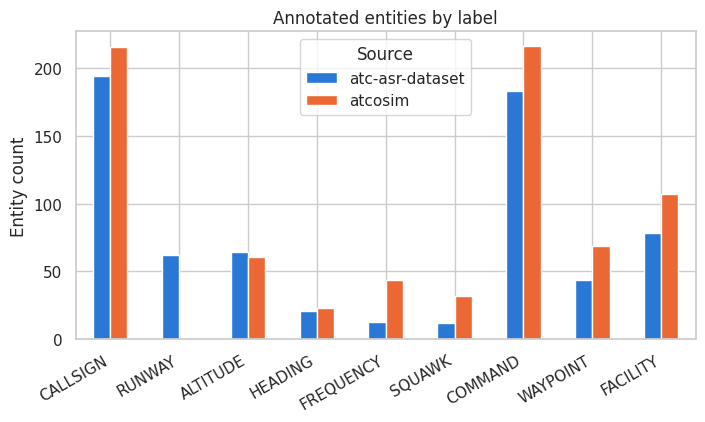

In [59]:
llm_rows = annotations[annotations["label_source"] == "llm"]
summary = pd.Series({
    "LLM-labeled utterances": len(llm_rows),
    "valid after retries (%)": round(100 * llm_rows["ok"].mean(), 1),
    "needed retry (%)": round(100 * (llm_rows["n_turns"] > 1).mean(), 1),
    "rejected tool calls / utterance": round(llm_rows["n_rejected"].mean(), 2),
    "utterances with no entity (%)": round(100 * (llm_rows["entities"].str.len() == 0).mean(), 1),
    "mean latency (s)": round(llm_rows["latency_s"].mean(), 2),
    "median latency (s)": round(llm_rows["latency_s"].median(), 2),
})
display(summary.to_frame("value"))

entity_df = pd.DataFrame([
    {"utterance_id": r.utterance_id, "dataset_source": r.dataset_source, **ent}
    for r in annotations.itertuples() for ent in r.entities
])
label_counts = (entity_df.groupby(["label", "dataset_source"]).size().unstack(fill_value=0)
                .reindex(list(NER_LABELS)).fillna(0).astype(int))

fig, ax = plt.subplots(figsize=(8, 4))
label_counts.plot.bar(ax=ax, color=[PALETTE[c] for c in label_counts.columns])
ax.set_title("Annotated entities by label")
ax.set_xlabel("")
ax.set_ylabel("Entity count")
ax.legend(title="Source")
plt.xticks(rotation=30, ha="right")
save_fig(fig, "ner_label_distribution")
plt.show()

In [60]:
RULE_LABEL = {"frequency": "FREQUENCY", "runway": "RUNWAY", "heading": "HEADING", "altitude": "ALTITUDE"}
_CALLSIGN_WORD_RE = re.compile(r"\b(?:" + "|".join(sorted(KNOWN_CALLSIGN_WORDS)) + r")\b")


def rule_spans(text: str) -> list[tuple[int, int, str]]:
    spans = [(m.start(), m.end(), RULE_LABEL[name])
             for name, pat in AVIATION_PATTERNS.items() for m in pat.finditer(text)]
    spans += [(m.start(), m.end(), "CALLSIGN") for m in _CALLSIGN_WORD_RE.finditer(text)]
    return spans


agree = {label: {"rule_spans": 0, "rule_hit": 0, "llm_spans": 0, "llm_hit": 0} for label in set(RULE_LABEL.values()) | {"CALLSIGN"}}
for r in llm_rows.itertuples():
    llm = entity_spans(r.text, r.entities)
    rules = rule_spans(r.text)
    for label, d in agree.items():
        rs = [s for s in rules if s[2] == label]
        ls = [s for s in llm if s[2] == label]
        d["rule_spans"] += len(rs)
        d["rule_hit"] += sum(any(_overlap(x, y) for y in ls) for x in rs)
        d["llm_spans"] += len(ls)
        d["llm_hit"] += sum(any(_overlap(x, y) for y in rs) for x in ls)

agreement_df = pd.DataFrame(agree).T
agreement_df["rule recall"] = (agreement_df["rule_hit"] / agreement_df["rule_spans"]).round(2)
agreement_df["rule precision"] = (agreement_df["llm_hit"] / agreement_df["llm_spans"]).round(2)
agreement_df

,rule_spans,rule_hit,llm_spans,llm_hit,rule recall,rule precision
FREQUENCY,37,36,51,36,0.97,0.71
CALLSIGN,141,133,369,133,0.94,0.36
HEADING,36,35,40,35,0.97,0.88
ALTITUDE,87,80,109,80,0.92,0.73
RUNWAY,60,59,59,59,0.98,1.00


### Manual Spot-Check

Read a random sample of the auto-accepted **LLM-labeled** rows, and of the rows routed to review (with their reasons), before scaling up. Entities are shown inline as `[text | LABEL]`.

In [61]:
def render(text: str, entities: list[dict]) -> str:
    spans = entity_spans(text, entities)
    out, pos = [], 0
    for s, e, label in spans:
        out.append(text[pos:s] + f"[{text[s:e]} | {label}]")
        pos = e
    return "".join(out) + text[pos:]


accepted_rows = llm_rows[~llm_rows["needs_review"]]
print("--- auto-accepted (random sample) ---")
for r in accepted_rows.sample(n=min(25, len(accepted_rows)), random_state=RANDOM_SEED).itertuples():
    print(f"({r.dataset_source}) {render(r.text, r.entities)}")

flagged_rows = llm_rows[llm_rows["needs_review"]]
print("\n--- routed to review (random sample) ---")
for r in flagged_rows.sample(n=min(10, len(flagged_rows)), random_state=RANDOM_SEED).itertuples():
    print(f"({r.dataset_source}) {render(r.text, r.entities)}   <- {', '.join(x for x in r.review_reasons if x not in INFO_ONLY_REASONS)}")

--- auto-accepted (random sample) ---
(atc-asr-dataset) at the airport its right of threshold of [runway three one | RUNWAY] will not cross your track
(atcosim) yeah just fly [heading of two eight zero | HEADING]
(atc-asr-dataset) descending [flight level one three zero | ALTITUDE] [csa six | CALLSIGN]
(atc-asr-dataset) [nor shuttle four five zero one | CALLSIGN] [descend | COMMAND] [flight level three two zero | ALTITUDE]
(atcosim) [speedbird seven seven whiskey whiskey | CALLSIGN] good morning [squawk two seven two zero | SQUAWK]
(atcosim) [speedway three four six nine | CALLSIGN] good morning [radar | FACILITY] [contact | COMMAND] [maintain | COMMAND] [flight level three three zero | ALTITUDE] [proceed | COMMAND] trasadingen zurich east fusse
(atc-asr-dataset) [skytravel one zero three six | CALLSIGN] roger [climb | COMMAND] to [flight level one six zero | ALTITUDE]
(atcosim) [aero lloyd five six two | CALLSIGN] [climb | COMMAND] to [flight level three three zero | ALTITUDE]
(atcosi

### Export: spaCy `DocBin` and BERT IOB2 JSONL

Only utterances that converged (`ok=True`) and were not routed to review are exported (set `NER_EXCLUDE_NEEDS_REVIEW = False` to keep them). Utterances with **no** entities are kept as negative examples. The existing `dataset_split` is preserved (`validation` is written as `dev`). The transcripts are already normalized, so BERT tokens are whitespace tokens and entity spans always fall on token boundaries. The BERT JSONL keeps the character-offset `entities` (with `span`) next to the word-level `tokens`/`ner_tags`, so a subword tokenizer can re-derive tags from `offset_mapping` when fine-tuning. For spaCy we use the standard tokenizer with `alignment_mode="strict"` so training matches inference. Any utterance whose spans do not align to spaCy tokens is dropped entirely (not partially labeled) and counted in the manifest.

In [62]:
SPLIT_NAMES = {"train": "train", "validation": "dev", "test": "test"}
BERT_LABELS = ["O"] + [f"{p}-{l}" for l in NER_LABELS for p in ("B", "I")]


def to_iob2(text: str, spans) -> tuple[list[str], list[str]]:
    toks = [(m.group(), m.start(), m.end()) for m in re.finditer(r"\S+", text)]
    tags = ["O"] * len(toks)
    for s, e, label in spans:
        idx = [i for i, (_, ts, te) in enumerate(toks) if ts >= s and te <= e]
        for k, i in enumerate(idx):
            tags[i] = ("B-" if k == 0 else "I-") + label
    return [t for t, _, _ in toks], tags


spacy_blank = spacy.blank("en")
docbins = {name: DocBin() for name in SPLIT_NAMES.values()}
bert_rows = {name: [] for name in SPLIT_NAMES.values()}
counts = {name: {"utterances": 0, "entities": 0, "gold_utterances": 0} for name in SPLIT_NAMES.values()}
dropped_invalid, dropped_review, dropped_spacy_align = 0, 0, 0

for r in annotations.itertuples():
    if not (r.ok or r.label_source == "gold"):
        dropped_invalid += 1
        continue
    if NER_EXCLUDE_NEEDS_REVIEW and r.needs_review:
        dropped_review += 1
        continue
    split = SPLIT_NAMES[r.dataset_split]
    spans = entity_spans(r.text, r.entities)
    doc = spacy_blank.make_doc(r.text)
    ents = [doc.char_span(s, e, label=l, alignment_mode="strict") for s, e, l in spans]
    if any(ent is None for ent in ents):
        dropped_spacy_align += 1
        continue
    doc.ents = ents
    docbins[split].add(doc)
    tokens, tags = to_iob2(r.text, spans)
    bert_rows[split].append({"id": r.utterance_id, "text": r.text, "tokens": tokens, "ner_tags": tags,
                             "entities": r.entities, "label_source": r.label_source,
                             "sample_reason": r.sample_reason})
    counts[split]["utterances"] += 1
    counts[split]["entities"] += len(spans)
    counts[split]["gold_utterances"] += r.label_source == "gold"

for split in SPLIT_NAMES.values():
    docbins[split].to_disk(os.path.join(NER_DIR, f"{split}.spacy"))
    with open(os.path.join(NER_DIR, f"{split}.jsonl"), "w") as f:
        f.writelines(json.dumps(row) + "\n" for row in bert_rows[split])

with open(os.path.join(NER_DIR, "label2id.json"), "w") as f:
    json.dump({l: i for i, l in enumerate(BERT_LABELS)}, f, indent=2)

manifest = {
    "llm": NER_MODEL_ID, "load_in_4bit": NER_LOAD_IN_4BIT,
    "second_llm": NER_SECOND_MODEL_ID, "exclude_needs_review": NER_EXCLUDE_NEEDS_REVIEW,
    "n_targeted_per_label": N_TARGETED_PER_LABEL, "sampling": ner_sample["sample_reason"].value_counts().to_dict(),
    "use_constraints": NER_USE_CONSTRAINTS, "use_hints": NER_USE_HINTS,
    "prompt_sha256": hashlib.sha256(SYSTEM_PROMPT.encode()).hexdigest()[:16],
    "n_ner_samples": N_NER_SAMPLES,
    "labels": list(NER_LABELS),
    "counts": counts,
    "dropped_not_ok": dropped_invalid,
    "dropped_needs_review": dropped_review,
    "dropped_spacy_misaligned": dropped_spacy_align,
}
with open(os.path.join(NER_DIR, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))

# The BERT files must load as a HF dataset with the expected columns
bert_check = load_dataset("json", data_files={s: os.path.join(NER_DIR, f"{s}.jsonl") for s in SPLIT_NAMES.values()})
print(bert_check)

{
  "llm": "Qwen/Qwen3.5-4B",
  "load_in_4bit": true,
  "second_llm": "Qwen/Qwen3.5-2B",
  "exclude_needs_review": true,
  "n_targeted_per_label": 40,
  "sampling": {
    "random": 299,
    "gold": 41,
    "targeted:SQUAWK": 40,
    "targeted:WAYPOINT": 40,
    "targeted:RUNWAY": 40,
    "targeted:HEADING": 40
  },
  "use_constraints": true,
  "use_hints": true,
  "prompt_sha256": "fd09afb89da85743",
  "n_ner_samples": 500,
  "labels": [
    "CALLSIGN",
    "RUNWAY",
    "ALTITUDE",
    "HEADING",
    "FREQUENCY",
    "SQUAWK",
    "COMMAND",
    "WAYPOINT",
    "FACILITY"
  ],
  "counts": {
    "train": {
      "utterances": 95,
      "entities": 237,
      "gold_utterances": 0
    },
    "dev": {
      "utterances": 32,
      "entities": 85,
      "gold_utterances": 18
    },
    "test": {
      "utterances": 41,
      "entities": 111,
      "gold_utterances": 23
    }
  },
  "dropped_not_ok": 40,
  "dropped_needs_review": 292,
  "dropped_spacy_misaligned": 0
}


DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'tokens', 'ner_tags', 'entities', 'label_source', 'sample_reason'],
        num_rows: 95
    })
    dev: Dataset({
        features: ['id', 'text', 'tokens', 'ner_tags', 'entities', 'label_source', 'sample_reason'],
        num_rows: 32
    })
    test: Dataset({
        features: ['id', 'text', 'tokens', 'ner_tags', 'entities', 'label_source', 'sample_reason'],
        num_rows: 41
    })
})


### Smoke Test: Train a spaCy NER and Measure Inference Speed

A blank `spacy.blank("en")` pipeline with only an NER component. With a few hundred annotated utterances the scores are not meaningful; the point is to prove the exported files train end to end and to get a first inference-throughput number, since speed is the reason we are not using the LLM at inference time.

In [63]:
N_SPACY_EPOCHS = 30


def load_examples(split: str) -> list[Example]:
    bin_ = DocBin().from_disk(os.path.join(NER_DIR, f"{split}.spacy"))
    return [Example(spacy_blank.make_doc(d.text), d) for d in bin_.get_docs(spacy_blank.vocab)]


train_ex, dev_ex, test_ex = (load_examples(s) for s in ("train", "dev", "test"))
print(f"train={len(train_ex)} dev={len(dev_ex)} test={len(test_ex)}")

random.seed(RANDOM_SEED)
spacy.util.fix_random_seed(RANDOM_SEED)  # seeds weight init too, so this smoke test is reproducible
ner_nlp = spacy.blank("en")
ner_pipe = ner_nlp.add_pipe("ner")
for label in NER_LABELS:
    ner_pipe.add_label(label)
optimizer = ner_nlp.initialize(lambda: train_ex)

for epoch in range(N_SPACY_EPOCHS):
    random.shuffle(train_ex)
    losses = {}
    for i in range(0, len(train_ex), 16):
        ner_nlp.update(train_ex[i:i + 16], sgd=optimizer, drop=0.2, losses=losses)
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1:>2}: loss={losses['ner']:.1f}  dev F1={ner_nlp.evaluate(dev_ex)['ents_f']:.3f}")

test_scores = ner_nlp.evaluate(test_ex)
print(f"\nTest  P={test_scores['ents_p']:.3f}  R={test_scores['ents_r']:.3f}  F1={test_scores['ents_f']:.3f}")

texts = [e.reference.text for e in test_ex + dev_ex + train_ex] * 5
t0 = time.perf_counter()
n_docs = sum(1 for _ in ner_nlp.pipe(texts, batch_size=64))
elapsed = time.perf_counter() - t0
print(f"spaCy CPU inference: {n_docs / elapsed:,.0f} utterances/s "
      f"({1000 * elapsed / n_docs:.2f} ms each)  vs. LLM mean {llm_rows['latency_s'].mean():.1f} s each")

ner_nlp.to_disk(os.path.join(NER_DIR, "spacy_smoke_test_model"))

train=95 dev=32 test=41


epoch 10: loss=292.3  dev F1=0.372


epoch 20: loss=74.5  dev F1=0.812


epoch 30: loss=9.8  dev F1=0.882

Test  P=0.757  R=0.757  F1=0.757


spaCy CPU inference: 3,495 utterances/s (0.29 ms each)  vs. LLM mean 12.4 s each


### Visual Check with displaCy

Numbers on 42 utterances are noisy, so we also look at the smoke-test model's predictions directly. For a random sample of test utterances, each pair below shows the **labels it was given** on top and the model's **prediction** underneath. The last group is a handful of hand-written probe sentences the model has never seen. Rendering is also saved as HTML under `res/figures/` for slides.

> **NOTE:** the model trains on only 120 utterances, so expect misses on rare labels (SQUAWK, WAYPOINT). The point is to confirm the end-to-end plumbing and spot systematic problems such as shifted span boundaries.

In [64]:
from spacy import displacy

DISPLACY_OPTIONS = {
    "ents": list(NER_LABELS),
    "colors": {"CALLSIGN": "#a5d8ff", "RUNWAY": "#ffd8a8", "ALTITUDE": "#b2f2bb", "HEADING": "#d0bfff",
               "FREQUENCY": "#ffec99", "SQUAWK": "#ffc9c9", "COMMAND": "#ced4da",
               "WAYPOINT": "#99e9f2", "FACILITY": "#fcc2d7"},
}
viz_docs, n_exact = [], 0
sample_ex = random.Random(RANDOM_SEED).sample(test_ex, min(8, len(test_ex)))
for ex in sample_ex:
    gold_doc, pred_doc = ex.reference, ner_nlp(ex.reference.text)
    gold_doc.user_data["title"], pred_doc.user_data["title"] = "labels", "model prediction"
    n_exact += [(e.start_char, e.end_char, e.label_) for e in gold_doc.ents] == [(e.start_char, e.end_char, e.label_) for e in pred_doc.ents]
    viz_docs += [gold_doc, pred_doc]
print(f"{n_exact}/{len(sample_ex)} shown test utterances are predicted exactly as labeled")
displacy.render(viz_docs, style="ent", jupyter=True, options=DISPLACY_OPTIONS)

PROBES = [  # hand-written, never seen in training
    "lufthansa four one alpha descend flight level one two zero",
    "speedbird two seven turn left heading two seven zero contact zurich one three three decimal four",
    "air france six six three runway two four left cleared to land squawk four two one zero",
    "csa five mike bravo proceed direct vemut climb flight level three one zero",
]
probe_docs = [ner_nlp(t) for t in PROBES]
for d in probe_docs:
    d.user_data["title"] = "probe"
    print([(e.text, e.label_) for e in d.ents])
displacy.render(probe_docs, style="ent", jupyter=True, options=DISPLACY_OPTIONS)

html = displacy.render(viz_docs + probe_docs, style="ent", jupyter=False, options=DISPLACY_OPTIONS)
with open(os.path.join(FIGURES_DIR, "ner_displacy_smoke_test.html"), "w") as f:
    f.write(html)

1/8 shown test utterances are predicted exactly as labeled


[('lufthansa four one alpha', 'CALLSIGN'), ('descend', 'COMMAND'), ('flight level one two zero', 'ALTITUDE')]
[('speedbird two seven', 'CALLSIGN'), ('turn left', 'COMMAND'), ('heading two seven zero', 'HEADING'), ('contact', 'COMMAND'), ('zurich', 'FACILITY'), ('one three three decimal four', 'FREQUENCY')]
[('air france six six three', 'CALLSIGN'), ('runway two four', 'RUNWAY'), ('cleared to land', 'ALTITUDE'), ('squawk four two one zero', 'SQUAWK')]
[('csa five mike', 'CALLSIGN'), ('proceed', 'COMMAND'), ('climb', 'COMMAND'), ('flight level three one zero', 'ALTITUDE')]


**Observation (prototype run: 200 utterances, 41 hand-labeled gold):**

- **Filtering:** of 15,219 de-duplicated utterances, 136 were single-word or greeting/filler-only and are excluded from the dataset.
- **Ablation on the gold set (120 spans, reviewed by the project author).** Span-level F1 rose from 0.60 (2B baseline) to 0.75 with per-label constraints and retry feedback, to 0.80 once rule-based hints were added (precision 0.87, recall 0.74). Qwen3.5-4B in 4-bit scored 0.81 (precision 0.83, recall 0.78), within noise of the 2B model with the same prompt. **Model size alone did not buy much accuracy.** The 4B model was chosen because it matched the gold exactly on 20/41 utterances versus 17/41 for 2B, which matters more than span-level F1 because one wrong span corrupts the whole training sentence.
- **Rule hints help where the rules apply** (ALTITUDE 0.60 to 0.97-1.00 F1, HEADING and FREQUENCY above 0.9), but they are blind to facilities and waypoints. The first version of the hint made the 2B model stop finding those entirely (WAYPOINT F1 0.00). Telling the model the list is incomplete fixed most of it.
- **Where the errors remain** (COMMAND about 0.66 and FACILITY about 0.55-0.63 F1 on the gold set): mostly *boundary and guideline ambiguity* ("ruzyne tower" as one FACILITY or two, partial callsigns like "aero lloyd" for "aero lloyd five three three", whether a pilot's "descending" is a COMMAND) plus recall misses on generic verbs ("identified", "continue"). Requiring the two models to agree exactly gives F1 0.92 on the agreed half of the gold set, but only 14 of those 20 utterances are fully correct, so shared errors remain.
- **Production run (4B 4-bit, 159 LLM-labeled utterances):** 96.9% valid after retries (5 utterances dropped), 28% needed at least one retry, about 10.8 s per utterance. The exported splits hold 120 train / 33 dev / 42 test utterances, with the gold utterances (18 dev, 23 test) using hand labels. Gold utterances are all in dev/test, so **train labels are LLM-only and the test score mixes gold and LLM labels.**
- **The spot-check still shows errors:** missed entities (e.g. "turkish one seven six niner" received no callsign), a speed ("speed one eight zero") labeled FREQUENCY, and "ils approach" labeled WAYPOINT.
- **Speed:** the smoke-test spaCy model runs at about 3,400 utterances/s on CPU (about 0.3 ms each) versus about 10.8 s per utterance for the LLM, roughly 36,000 times faster. Its test F1 of 0.71 (seeded and reproducible) on 42 utterances only shows the exported files train end to end; it is not a quality estimate.
- **displaCy check of the smoke-test model:** only 1 of 8 randomly sampled test utterances is predicted exactly as labeled. On four hand-written probe sentences it gets callsigns, runways, headings, frequencies and altitudes right, but labels "squawk four two one zero" as a CALLSIGN and "proceed direct vemut" as a single COMMAND (no WAYPOINT). That is the expected pattern for labels with very few training examples (120 training utterances), and it argues for more data before judging the model.

**Before scaling up:** (1) settle the boundary guidelines above (the gold labels themselves have now been reviewed), since they cap what any annotator can score; (2) add constraints for the observed error types (e.g. a FREQUENCY must not follow "speed"); (3) route utterances that needed retries, ended with no entity, or have model disagreement to human review instead of straight into training; (4) then scale `N_NER_SAMPLES` up.


**Data format:** gold labels and the exported BERT/spaCy JSONL carry explicit character offsets (`span: [start, end)`, verified against the text), so labels no longer depend on alignment order.

## Summary

We compared three ASR conditions on the same fixed held-out test split: the generic baseline (`openai/whisper-medium.en`), a domain-adapted comparison model (`jacktol/whisper-medium.en-fine-tuned-for-ATC`), and our own fine-tune (`openai/whisper-small.en-finetuned-atc-subset`). WER was reported both overall and broken down by `dataset_source` (Sections B/C), and all results were saved to `data/processed/asr_results/` as CSV files (`baseline_whisper_medium_en`, `comparison_whisper_medium_en_atc`, `finetuned_whisper_small_en_atc_subset`, `combined_asr_results`, `combined_asr_summary`) so they're not lost when the notebook output is cleared.

Beyond WER, Section D adds aviation-specific proxy metrics -- callsign, numeric, and command recall, plus altitude/heading/runway/frequency presence detection -- along with a WER-vs-entity-recall correlation check to see how well aggregate WER actually tracks the things that matter operationally. Error analysis is covered by the sample review in Sections B/C and the alignment-based error taxonomy above.

For fine-tuning, we went with `openai/whisper-small.en` instead of medium.en to fit within the 8GB VRAM constraint, training on a 1,000-row stratified subset for 3 epochs with `per_device_train_batch_size=4`/`gradient_accumulation_steps=8` (`batch_size=8` caused bad VRAM-pressure slowdown on this GPU). Interestingly, it beat the medium.en baseline in both domains despite having a quarter of the parameters. It doesn't generalize to real audio anywhere near as well as jacktol's model. This is understandable given the difference in model size and training data volume. But it does edge it out on ATCOSIM, albeit not a fair comparison since jacktol's model never saw ATCOSIM while the fine-tuned whisper-small.en model did.

**Known limitations:** the `jacktol` comparison model's numbers on `atc-asr-dataset` carry an unverified train/test-overlap risk; fine-tuned small whisper model's ATCOSIM evaluation results aren't a fair generalization test against jacktol's model for the same reason in reverse (ATCOSIM was in training data for fine-tuning the small whisper model); the aviation-entity metrics are all proxy/heuristic since neither corpus has ground-truth entity spans; the digit-word normalizer still doesn't handle "nine" vs. "niner" or decompose alphanumeric callsigns; and the fine-tuning in this notebook only used 1,000 samples at 3 epochs which is not anywhere close to the full ~13,956 samples in the train split.

**Next steps:** This notebook is intended as a prototype environment to get things working and test things out. The next step is to build a standalone `ASRTrainingPipeline` (and companion `ASREvaluationPipeline`) in `src/` following the same pattern as `DataIngestPipeline`. This will be a self-contained class that can be invoked from the command line without a Jupyter kernel and avoid the memory overhead and output size limitations that come with running full training jobs inside a notebook. Similar to how a YOLO training run works, the pipeline should handle the full loop end-to-end (e.g., loading the preprocessed dataset, fine-tuning, per-epoch checkpoints, and writing evaluation outputs such as per-utterance scores, summary CSVs, figures to a structured `res/` subdirectory so results are organized and reproducible across runs). The inline helper functions and classes defined in this notebook are intended for reuse in the standalone training/evaluation process (e.g., `expand_digits_to_atc_words`, `normalize_for_scoring`, `transcribe_batch`, `token_recall`, etc.).